# Laboratorio 7 — Spark MLlib
**CC3066 Data Science — Universidad del Valle de Guatemala — Semestre II 2026**

Análisis de salarios de personas asalariadas con la **Encuesta Nacional de Empleo e Ingresos Continua (ENEIC)** del INE.

- **Desarrollo / entrenamiento:** trimestres I–IV de 2025.
- **Prueba final:** trimestre I de 2026.

Todo el procesamiento analítico se realiza con **PySpark 3.5 (API de DataFrames / `pyspark.ml`)**. Los archivos Excel se leen con `openpyxl` (Spark no tiene lector nativo de Excel), se convierten a DataFrames de Spark con esquema explícito y se guardan en Parquet. A pandas sólo se transfieren tablas agregadas o muestras (≤ 10,000 registros) para graficar.

**Contenido:** secciones 1–4 (análisis exploratorio y segmentación) y 5–8 (modelado supervisado: regresión lineal, Random Forest, evaluación en 2026 y análisis de errores).

**Ejecución:** el notebook corre de principio a fin sin pasos manuales. Si los Excel no están en `data/raw/`, se descargan automáticamente del sitio del INE. Ver `README.md` para levantar el ambiente con Docker.

```
data/raw/        <- archivos .xlsx del INE (se descargan si faltan; no versionados)
data/parquet/    <- salidas Parquet generadas por este notebook
modelos/         <- pipelines de MLlib guardados
```

In [1]:
import os, json, math, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import openpyxl

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator, RegressionEvaluator
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor

%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
SEED = 42

spark = (SparkSession.builder
         .appName("Lab7-ENEIC")
         .master("local[*]")
         .config("spark.driver.memory", "6g")
         .config("spark.sql.shuffle.partitions", "16")
         .config("spark.ui.showConsoleProgress", "false")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 23:47:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1


---
# 1. Carga, armonización y calidad de datos

## 1.1 Archivos y columnas requeridas

Cada archivo se identifica por su **procedencia** (no por la columna `TRIMESTRE`). Se crean `archivo_origen`, `periodo_archivo`, `anio_archivo` y `trimestre_calendario` a partir de esta tabla.

In [2]:
RAW_DIR = "data/raw"
PQ_DIR = "data/parquet"
os.makedirs(PQ_DIR, exist_ok=True)

ARCHIVOS = [
    # archivo, periodo_archivo, anio_archivo, trimestre_calendario, uso
    ("Personas_ENEIC_T1_2025.xlsx",                 "2025T1", 2025, 1, "train"),
    ("Personas-ENEIC-T2-2025.xlsx",                 "2025T2", 2025, 2, "train"),
    ("Base-de-datos-Personas-ENEIC-III-2025.xlsx",  "2025T3", 2025, 3, "train"),
    ("Base-de-datos-Personas-ENEIC-IV-2025.xlsx",   "2025T4", 2025, 4, "validación"),
    ("Base-de-datos-Personas-ENEIC-I-2026.xlsx",    "2026T1", 2026, 1, "test"),
]

# Fuente oficial: https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/
URLS_INE = {
    "Personas_ENEIC_T1_2025.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas_ENEIC_T1_2025.xlsx",
    "Personas-ENEIC-T2-2025.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas-ENEIC-T2-2025.xlsx",
    "Base-de-datos-Personas-ENEIC-III-2025.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/05/Base-de-datos-Personas-ENEIC-III-2025.xlsx",
    "Base-de-datos-Personas-ENEIC-IV-2025.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/06/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
    "Base-de-datos-Personas-ENEIC-I-2026.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/09/Base-de-datos-Personas-ENEIC-I-2026.xlsx",
    "Diccionario-Personas-ENEIC-I-2026.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/09/Diccionario-Personas-ENEIC-I-2026.xlsx",
}

import urllib.request
os.makedirs(RAW_DIR, exist_ok=True)
for nombre, url in URLS_INE.items():
    ruta = f"{RAW_DIR}/{nombre}"
    if not os.path.exists(ruta):
        print("Descargando", nombre, "...")
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as r, open(ruta + ".part", "wb") as f:
            f.write(r.read())
        os.replace(ruta + ".part", ruta)
print("Archivos en data/raw:", sorted(os.listdir(RAW_DIR)))

# Columnas originales requeridas
COLS_ORIG = ["ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
             "OCUPADOS", "P02A03", "P05C07A", "P05C07B", "P05H01A",
             "P03A03A", "P05C16", "P05D01"]

Archivos en data/raw: ['Base-de-datos-Personas-ENEIC-I-2026.xlsx', 'Base-de-datos-Personas-ENEIC-III-2025.xlsx', 'Base-de-datos-Personas-ENEIC-IV-2025.xlsx', 'Diccionario-Personas-ENEIC-I-2026.xlsx', 'Personas-ENEIC-T2-2025.xlsx', 'Personas_ENEIC_T1_2025.xlsx']


## 1.2 Lectura individual de cada Excel → Parquet crudo

Cada archivo se procesa **por separado** para controlar memoria:

1. `openpyxl` en modo `read_only` recorre las filas y extrae **sólo** las 14 columnas requeridas, localizándolas **por nombre** en el encabezado (no por posición).
2. Como un mismo código puede llegar como número (`2`, `2.0`) o como texto (`'2'`, `' 2 '`), todo valor se normaliza a una **cadena canónica** (`2.0 → "2"`, espacios recortados, vacío → nulo). Así el DataFrame de Spark se crea con un esquema explícito homogéneo (`StringType`) y la conversión numérica se hace después, de forma idéntica para los cinco archivos.
3. El resultado se guarda en `data/parquet/crudo/<periodo>` (si ya existe, se reutiliza para no releer el Excel).

In [3]:
def normalizar(v):
    # Representación canónica en texto de un valor de celda
    if v is None:
        return None
    if isinstance(v, bool):
        return str(int(v))
    if isinstance(v, int):
        return str(v)
    if isinstance(v, float):
        if math.isfinite(v) and v.is_integer():
            return str(int(v))
        return repr(v)          # conserva 'nan' / 'inf' para poder detectarlos después
    s = str(v).strip()
    return s if s != "" else None

ESQUEMA_CRUDO = T.StructType([T.StructField(c, T.StringType(), True) for c in COLS_ORIG])

def excel_a_parquet(archivo, periodo):
    destino = f"{PQ_DIR}/crudo/{periodo}"
    meta_path = f"{PQ_DIR}/crudo/{periodo}_meta.json"
    if os.path.exists(destino) and os.path.exists(meta_path):
        with open(meta_path) as f:
            return json.load(f)
    t0 = time.time()
    wb = openpyxl.load_workbook(f"{RAW_DIR}/{archivo}", read_only=True, data_only=True)
    ws = wb[wb.sheetnames[0]]
    filas = ws.iter_rows(values_only=True)
    encabezado = [str(h).strip().upper() if h is not None else "" for h in next(filas)]
    idx = {c: encabezado.index(c) for c in COLS_ORIG}
    datos = []
    for fila in filas:
        if fila is None or all(v is None for v in fila):
            continue            # filas completamente vacías al final de la hoja
        datos.append(tuple(normalizar(fila[idx[c]]) for c in COLS_ORIG))
    wb.close()
    sdf = spark.createDataFrame(datos, schema=ESQUEMA_CRUDO)
    sdf.write.mode("overwrite").parquet(destino)
    meta = {"archivo": archivo, "hoja": ws.title, "n_columnas": len([h for h in encabezado if h]),
            "n_filas": len(datos), "posiciones": {c: idx[c] + 1 for c in COLS_ORIG}}
    with open(meta_path, "w") as f:
        json.dump(meta, f)
    print(f"{periodo}: {len(datos):,} filas leídas en {time.time()-t0:.0f}s")
    return meta

META = {p: excel_a_parquet(a, p) for a, p, *_ in ARCHIVOS}
pd.DataFrame({p: {"hoja": m["hoja"], "columnas originales": m["n_columnas"], "registros originales": m["n_filas"]}
              for p, m in META.items()}).T

,hoja,columnas originales,registros originales
2025T1,Personas_ENEIC_T1_2025,270,51588
2025T2,Personas ENEIC T2-2025,270,51167
2025T3,Personas ENEIC T3-2025,270,51583
2025T4,Base de datos Personas ENEIC IV,302,49338
2026T1,Personas_ENEIC_T1-2026,270,49843


Los conteos coinciden con los de la tabla del enunciado (51,588 / 51,167 / 51,583 / 49,338 / 49,843) y el archivo IV‑2025 tiene 302 columnas frente a 270 de los demás.

### ¿Por qué IV‑2025 no puede apilarse por posición?
La siguiente tabla muestra la **posición (1‑based)** de cada columna requerida dentro de su archivo:

In [4]:
posiciones = pd.DataFrame({p: m["posiciones"] for p, m in META.items()})
posiciones["¿misma posición en todos?"] = posiciones.nunique(axis=1).eq(1)
posiciones

,2025T1,2025T2,2025T3,2025T4,2026T1,¿misma posición en todos?
ANIO,1,1,1,1,1,True
TRIMESTRE,2,2,2,2,2,True
DOMINIO,3,3,3,3,3,True
NUM_HOGAR,4,4,4,4,4,True
NUM_PERSONA,7,7,7,7,7,True
FACTOR,5,5,5,5,5,True
OCUPADOS,266,266,266,298,266,False
P02A03,13,13,13,9,13,False
P05C07A,68,68,68,61,68,False
P05C07B,69,69,69,62,69,False


IV‑2025 tiene **32 columnas adicionales** y un orden distinto: por ejemplo la edad (`P02A03`) está en la columna 9 en lugar de la 13, y `OCUPADOS` en la 298 en lugar de la 266. Un `union()` posicional pegaría la edad de un archivo con otra variable del otro (p. ej. un código de residencia), produciendo datos silenciosamente corruptos (o fallaría por diferente número de columnas). Por eso se selecciona cada variable **por nombre** y se une con **`unionByName`**, que empareja columnas por su nombre y no por su posición.

## 1.3 Homologación de tipos e identificación del período

- Variables numéricas continuas (`P02A03`, `P05C07A`, `P05C07B`, `P05H01A`, `P05D01`, `FACTOR`) → `double`. Un texto no numérico queda como nulo.
- Códigos (`DOMINIO`, `OCUPADOS`, `P05C16`, `P03A03A`, `ANIO`, `TRIMESTRE`) → `int` **sólo si** el valor es un número entero; de lo contrario, nulo.
- Identificadores `NUM_HOGAR`, `NUM_PERSONA` → `long`.
- `TRIMESTRE` se **conserva sin modificar**; el período se toma del archivo de procedencia.

In [5]:
def a_double(c):
    return F.col(c).cast("double")

def a_codigo(c, tipo="int"):
    d = F.col(c).cast("double")
    return F.when(d.isNotNull() & ~F.isnan(d) & (d == F.floor(d)), d.cast(tipo))

def cargar_homologado(archivo, periodo, anio, trim, uso):
    return (spark.read.parquet(f"{PQ_DIR}/crudo/{periodo}")
            .select(
                F.lit(archivo).alias("archivo_origen"),
                F.lit(periodo).alias("periodo_archivo"),
                F.lit(anio).cast("int").alias("anio_archivo"),
                F.lit(trim).cast("int").alias("trimestre_calendario"),
                a_codigo("ANIO").alias("ANIO"),
                a_codigo("TRIMESTRE").alias("TRIMESTRE"),
                a_codigo("NUM_HOGAR", "long").alias("NUM_HOGAR"),
                a_codigo("NUM_PERSONA", "long").alias("NUM_PERSONA"),
                a_double("FACTOR").alias("FACTOR"),
                a_codigo("DOMINIO").alias("dominio_cod"),
                a_codigo("OCUPADOS").alias("ocupado"),
                a_double("P02A03").alias("edad"),
                a_double("P05C07A").alias("antiguedad_anios"),
                a_double("P05C07B").alias("antiguedad_meses"),
                a_double("P05H01A").alias("horas_semanales"),
                a_codigo("P03A03A").alias("nivel_educativo_cod"),
                a_codigo("P05C16").alias("categoria_ocupacional_cod"),
                a_double("P05D01").alias("salario_mensual"),
            ))

dfs = {p: cargar_homologado(a, p, y, t, u) for a, p, y, t, u in ARCHIVOS}

# Unión de los cuatro archivos de 2025 por NOMBRE de columna
from functools import reduce
df25_raw = reduce(lambda a, b: a.unionByName(b), [dfs[p] for p in ["2025T1", "2025T2", "2025T3", "2025T4"]])
df26_raw = dfs["2026T1"]
df_all_raw = df25_raw.unionByName(df26_raw).persist()

print(f"2025 (unión): {df25_raw.count():,} registros | 2026: {df26_raw.count():,} registros")
df_all_raw.printSchema()

2025 (unión): 203,676 registros | 2026: 49,843 registros
root
 |-- archivo_origen: string (nullable = false)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: long (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- dominio_cod: integer (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- salario_mensual: double (nullable = true)



**Esquema y cinco registros** de las columnas seleccionadas (unión 2025):

In [6]:
df25_raw.show(5, truncate=False)

+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+-----------+-------+----+----------------+----------------+---------------+-------------------+-------------------------+---------------+
|archivo_origen             |periodo_archivo|anio_archivo|trimestre_calendario|ANIO|TRIMESTRE|NUM_HOGAR|NUM_PERSONA|FACTOR|dominio_cod|ocupado|edad|antiguedad_anios|antiguedad_meses|horas_semanales|nivel_educativo_cod|categoria_ocupacional_cod|salario_mensual|
+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+-----------+-------+----+----------------+----------------+---------------+-------------------+-------------------------+---------------+
|Personas_ENEIC_T1_2025.xlsx|2025T1         |2025        |1                   |2025|2        |16033    |2          |356.0 |2          |1      |44.0|6.0             |0.0             |50.0           |5                  

### Valores originales de `TRIMESTRE` por archivo
Se verifica que la columna original no coincide con el trimestre calendario (y que en II‑2025 hay registros con `TRIMESTRE = 2`). Por eso **no** se resta 1: esa regla asignaría 175 registros de II‑2025 al primer trimestre y convertiría el 6 de I‑2026 en un inexistente "trimestre 5".

In [7]:
(df_all_raw.groupBy("periodo_archivo", "trimestre_calendario", "TRIMESTRE").count()
 .orderBy("periodo_archivo", "TRIMESTRE").toPandas())

,periodo_archivo,trimestre_calendario,TRIMESTRE,count
0,2025T1,1,2,51588
1,2025T2,2,2,175
2,2025T2,2,3,50992
3,2025T3,3,4,51583
4,2025T4,4,5,49338
5,2026T1,1,6,49843


## 1.4 Faltantes por variable **antes** de aplicar filtros

Se cuentan los nulos tras la homologación (incluye celdas vacías y valores no convertibles a número/código).

In [8]:
VARS_SEL = ["ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "dominio_cod", "ocupado", "edad",
            "antiguedad_anios", "antiguedad_meses", "horas_semanales", "nivel_educativo_cod",
            "categoria_ocupacional_cod", "salario_mensual"]

def tabla_faltantes(df, etiqueta):
    n = df.count()
    fila = df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in VARS_SEL]).first().asDict()
    return pd.DataFrame({f"{etiqueta} faltantes": fila,
                         f"{etiqueta} %": {k: round(100 * v / n, 2) for k, v in fila.items()}})

faltantes = pd.concat([tabla_faltantes(df25_raw, "2025"), tabla_faltantes(df26_raw, "2026")], axis=1)
faltantes

,2025 faltantes,2025 %,2026 faltantes,2026 %
ANIO,0,0.00,0,0.00
TRIMESTRE,0,0.00,0,0.00
NUM_HOGAR,0,0.00,0,0.00
NUM_PERSONA,0,0.00,0,0.00
FACTOR,0,0.00,0,0.00
dominio_cod,0,0.00,0,0.00
ocupado,115454,56.69,28109,56.40
edad,0,0.00,0,0.00
antiguedad_anios,115454,56.69,28109,56.40
antiguedad_meses,115454,56.69,28109,56.40


Para distinguir **faltantes estructurales** (la pregunta no corresponde) de **no respuesta**, se repite el conteo sólo entre personas de 15+ años, ocupadas y asalariadas (a quienes sí se les debía preguntar por salario, antigüedad y horas):

In [9]:
cond_aplica = (F.col("edad") >= 15) & (F.col("ocupado") == 1) & F.col("categoria_ocupacional_cod").isin(1, 2, 3, 4)
pd.concat([tabla_faltantes(df25_raw.filter(cond_aplica), "2025 asalariados"),
           tabla_faltantes(df26_raw.filter(cond_aplica), "2026 asalariados")], axis=1)

,2025 asalariados faltantes,2025 asalariados %,2026 asalariados faltantes,2026 asalariados %
ANIO,0,0.0,0,0.0
TRIMESTRE,0,0.0,0,0.0
NUM_HOGAR,0,0.0,0,0.0
NUM_PERSONA,0,0.0,0,0.0
FACTOR,0,0.0,0,0.0
dominio_cod,0,0.0,0,0.0
ocupado,0,0.0,0,0.0
edad,0,0.0,0,0.0
antiguedad_anios,0,0.0,0,0.0
antiguedad_meses,0,0.0,0,0.0


**Interpretación.** En la base completa, las variables laborales (`ocupado`, `categoria_ocupacional`, antigüedad, horas y sobre todo `salario_mensual`) tienen porcentajes de faltantes muy altos. Esto **no** es un problema de calidad: la ENEIC aplica *saltos de flujo*; a niños, inactivos, desocupados o trabajadores por cuenta propia simplemente no se les pregunta por un salario. Cuando la tabla se restringe a quienes sí debían responder (asalariados ocupados de 15+), los faltantes **caen a cero**: en estas bases no hay no respuesta registrada en las variables del análisis.

Nota sobre `OCUPADOS`: según el diccionario, la variable sólo toma el valor 1 (población ocupada). Su "faltante" no es una respuesta perdida: significa que la persona **no** está ocupada (es desocupada, inactiva o menor de edad). `nivel_educativo` falta para ≈ 13% de los registros, y **todos** ellos son niños menores de 7 años, a quienes no se les aplica la pregunta (faltante estructural).

### ¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?
- **No corresponde (faltante estructural / por diseño):** el cuestionario excluye a la persona de la pregunta (p. ej. salario de un menor, de un inactivo o de un cuenta propia). El valor *no existe* conceptualmente; imputarlo no tiene sentido y la persona simplemente no pertenece a la población de análisis.
- **Respuesta no registrada (no respuesta):** la pregunta sí aplicaba, pero la persona no sabe, no quiso responder o hubo un error de captura. El valor existe pero es desconocido; puede introducir sesgo si la no respuesta está relacionada con el salario (p. ej. personas de ingresos altos que no revelan su sueldo). En este laboratorio esos registros se **excluyen y se contabilizan**, no se imputan.

## 1.5 Unicidad de la clave `periodo_archivo` + `NUM_HOGAR` + `NUM_PERSONA`

In [10]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
dup = df_all_raw.groupBy(CLAVE).count().filter("count > 1")
print("Claves nulas:", df_all_raw.filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count())
print("Claves duplicadas (antes de filtros):", dup.count(),
      "| registros involucrados:", dup.agg(F.coalesce(F.sum("count"), F.lit(0))).first()[0])
dup.groupBy("periodo_archivo").agg(F.count("*").alias("claves_duplicadas"), F.sum("count").alias("registros")).toPandas()

Claves nulas: 0


Claves duplicadas (antes de filtros): 0 | registros involucrados: 0


,periodo_archivo,claves_duplicadas,registros


In [11]:
# Si hubiera claves repetidas: ¿son repeticiones exactas o registros en conflicto?
cols_contenido = [c for c in df_all_raw.columns if c not in CLAVE]
if dup.count() > 0:
    detalle = (df_all_raw.join(dup.select(CLAVE), CLAVE)
               .groupBy(CLAVE)
               .agg(F.count("*").alias("filas"),
                    F.countDistinct(F.to_json(F.struct(*cols_contenido))).alias("versiones_distintas")))
    resumen_dup = detalle.withColumn("tipo", F.when(F.col("versiones_distintas") == 1, "repetición exacta")
                                               .otherwise("registros en conflicto"))
    display(resumen_dup.groupBy("periodo_archivo", "tipo").count().toPandas())
    display(df_all_raw.join(dup.select(CLAVE).limit(3), CLAVE).orderBy(CLAVE).toPandas())
else:
    print("La combinación periodo_archivo + NUM_HOGAR + NUM_PERSONA es única en todos los archivos.")

La combinación periodo_archivo + NUM_HOGAR + NUM_PERSONA es única en todos los archivos.


### Unicidad entre períodos (diseño longitudinal)
La clave **sin** el período sí se repite: la ENEIC es un panel rotativo y el mismo hogar/persona puede observarse en varios trimestres.

In [12]:
visitas = (df25_raw.groupBy("NUM_HOGAR", "NUM_PERSONA")
           .agg(F.countDistinct("periodo_archivo").alias("trimestres_observado")))
visitas.groupBy("trimestres_observado").count().orderBy("trimestres_observado").toPandas()

,trimestres_observado,count
0,1,31273
1,2,27771
2,3,16279
3,4,17006


### ¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado?
Porque **no es un duplicado**: son dos observaciones distintas de la misma persona en momentos diferentes, cada una con su propia edad, horas, antigüedad y salario de ese trimestre. La ENEIC es un diseño longitudinal con rotación, y cada trimestre es una muestra completa y válida por sí misma (con su propio `FACTOR`). Eliminar una de las visitas: (1) sesgaría las distribuciones de los trimestres afectados, (2) destruiría la información de cambio en el tiempo que da valor al panel y (3) rompería la representatividad de cada corte trimestral. Un duplicado sólo existe **dentro** de un mismo período (misma clave `periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`). Como consecuencia, el número de filas acumuladas en 2025 **no** equivale al número de personas distintas.

## 1.6 Construcción de variables y filtros de la población analítica

**Categóricas** (validadas contra el diccionario de datos del INE; cualquier código ausente o no reconocido → `DESCONOCIDO`; el código educativo **0 = "Ninguno"** es un valor válido):

| Variable | Códigos válidos |
|---|---|
| `nivel_educativo` (`P03A03A`) | 0 Ninguno, 1 Preprimaria, 2 Primaria, 3 Básico, 4 Diversificado, 5 Superior, 6 Maestría, 7 Doctorado |
| `categoria_ocupacional` (`P05C16`) | 1 Gobierno, 2 Empresa privada, 3 Jornalero/peón, 4 Servicio doméstico (5–9 no asalariados) |
| `dominio` (`DOMINIO`) | 1 Urbano metropolitano, 2 Resto urbano, 3 Rural nacional |

**Antigüedad (años)** = `antiguedad_anios + antiguedad_meses / 12`.

**Filtros**, aplicados siempre **en el mismo orden** (un registro se contabiliza en el primer paso que no cumple):
1. Edad finita y ≥ 15.
2. Ocupado (`OCUPADOS = 1`).
3. Asalariado (`P05C16` ∈ {1, 2, 3, 4}).
4. Salario `P05D01` numérico, finito y > 0.
5. Años de antigüedad finitos y ≥ 0.
6. Meses de antigüedad enteros entre 0 y 11.
7. Antigüedad calculada ≤ edad.
8. Horas habituales > 0 y ≤ 168.

In [13]:
NIVEL_EDU = {0: "Ninguno", 1: "Preprimaria", 2: "Primaria", 3: "Básico", 4: "Diversificado",
             5: "Superior", 6: "Maestría", 7: "Doctorado"}
CAT_OCUP = {1: "Gobierno", 2: "Empresa privada", 3: "Jornalero/peón", 4: "Servicio doméstico"}
DOMINIO = {1: "Urbano metropolitano", 2: "Resto urbano", 3: "Rural nacional"}
ORDEN_EDU = list(NIVEL_EDU.values()) + ["DESCONOCIDO"]
ORDEN_CAT = list(CAT_OCUP.values()) + ["DESCONOCIDO"]
ORDEN_DOM = list(DOMINIO.values()) + ["DESCONOCIDO"]

def etiquetar(col, mapa):
    m = F.create_map(*[x for k, v in mapa.items() for x in (F.lit(k), F.lit(v))])
    return F.coalesce(m[F.col(col)], F.lit("DESCONOCIDO"))

def finito(c):
    c = F.col(c) if isinstance(c, str) else c
    return c.isNotNull() & ~F.isnan(c) & (c != float("inf")) & (c != float("-inf"))

def construir(df):
    return (df
            .withColumn("nivel_educativo", etiquetar("nivel_educativo_cod", NIVEL_EDU))
            .withColumn("categoria_ocupacional", etiquetar("categoria_ocupacional_cod", CAT_OCUP))
            .withColumn("dominio", etiquetar("dominio_cod", DOMINIO))
            .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12))

PASOS = [
    ("1. Edad finita y >= 15",                finito("edad") & (F.col("edad") >= 15)),
    ("2. Ocupado (OCUPADOS = 1)",             F.col("ocupado") == 1),
    ("3. Asalariado (P05C16 en 1-4)",         F.col("categoria_ocupacional_cod").isin(1, 2, 3, 4)),
    ("4. Salario numérico, finito y > 0",     finito("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("5. Años de antigüedad finitos y >= 0",  finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
    ("6. Meses enteros entre 0 y 11",         finito("antiguedad_meses") & (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))
                                              & F.col("antiguedad_meses").between(0, 11)),
    ("7. Antigüedad calculada <= edad",       F.col("antiguedad") <= F.col("edad")),
    ("8. Horas habituales > 0 y <= 168",      finito("horas_semanales") & (F.col("horas_semanales") > 0)
                                              & (F.col("horas_semanales") <= 168)),
]

def marcar_exclusion(df):
    # paso_excluido = número del PRIMER filtro que el registro no cumple (0 = cumple todos).
    # coalesce(cond, False) hace que un criterio no evaluable (nulo) cuente como no cumplido.
    expr = F.lit(0)
    for i in range(len(PASOS), 0, -1):
        expr = F.when(~F.coalesce(PASOS[i - 1][1], F.lit(False)), F.lit(i)).otherwise(expr)
    return construir(df).withColumn("paso_excluido", expr)

df_all_marcado = marcar_exclusion(df_all_raw).persist()

conteo = (df_all_marcado.groupBy("periodo_archivo").pivot("paso_excluido", list(range(len(PASOS) + 1)))
          .count().fillna(0).toPandas().set_index("periodo_archivo").sort_index())
conteo.columns = [int(c) for c in conteo.columns]
periodos = conteo.index.tolist()
tabla = pd.DataFrame(index=["Registros originales"] + [f"Excluidos en {n}" for n, _ in PASOS] + ["Registros finales"],
                     columns=periodos, dtype="int64")
tabla.loc["Registros originales"] = conteo.sum(axis=1)
for i, (n, _) in enumerate(PASOS, start=1):
    tabla.loc[f"Excluidos en {n}"] = conteo[i]
tabla.loc["Registros finales"] = conteo[0]
tabla["Total 2025"] = tabla[[p for p in periodos if p.startswith("2025")]].sum(axis=1)
tabla = tabla.astype("int64")
display(tabla)
print("% de registros conservados:")
(100 * tabla.loc["Registros finales"] / tabla.loc["Registros originales"]).round(2).to_frame("% conservado").T

,2025T1,2025T2,2025T3,2025T4,2026T1,Total 2025
Registros originales,51588,51167,51583,49338,49843,203676
Excluidos en 1. Edad finita y >= 15,16253,15882,15767,14984,14803,62886
Excluidos en 2. Ocupado (OCUPADOS = 1),13062,12942,13443,13121,13306,52568
Excluidos en 3. Asalariado (P05C16 en 1-4),8854,8851,8923,8569,8476,35197
"Excluidos en 4. Salario numérico, finito y > 0",0,0,0,0,0,0
Excluidos en 5. Años de antigüedad finitos y >= 0,0,0,0,0,0,0
Excluidos en 6. Meses enteros entre 0 y 11,0,0,0,0,0,0
Excluidos en 7. Antigüedad calculada <= edad,0,0,0,0,0,0
Excluidos en 8. Horas habituales > 0 y <= 168,0,0,0,0,0,0
Registros finales,13419,13492,13450,12664,13258,53025


% de registros conservados:


,2025T1,2025T2,2025T3,2025T4,2026T1,Total 2025
% conservado,26.01,26.37,26.07,25.67,26.6,26.03


**Interpretación del filtrado.** Todas las exclusiones ocurren en los tres primeros pasos, que definen la *población* (menores de 15 años ≈ 31%, no ocupados ≈ 26% y ocupados no asalariados ≈ 17% del total de 2025). Una vez restringida la base a asalariados ocupados de 15+ años, **ningún** registro falla los criterios de calidad (pasos 4–8): el salario, la antigüedad y las horas están completos, son positivos/consistentes y la antigüedad nunca supera la edad. Esto indica que el INE entrega estas variables ya validadas (y posiblemente con valores imputados en la no respuesta). El porcentaje conservado es muy estable entre archivos (≈ 26%), lo que confirma que las cinco bases se armonizaron de la misma forma. La población analítica final es de **53,025 registros en 2025** y **13,258 en 2026T1**.

Detalle adicional (después del filtro 3, entre asalariados): **causa** por la cual el salario no es válido, para distinguir nulos de ceros/negativos.

In [14]:
excl_sal = (df_all_marcado.filter(F.col("paso_excluido") == 4)
 .withColumn("motivo", F.when(F.col("salario_mensual").isNull(), "nulo / no numérico")
                        .when(~finito("salario_mensual"), "no finito")
                        .when(F.col("salario_mensual") == 0, "igual a 0")
                        .otherwise("negativo"))
 .groupBy("periodo_archivo").pivot("motivo").count().fillna(0).orderBy("periodo_archivo").toPandas())
excl_sal if len(excl_sal) else print("Ningún asalariado ocupado de 15+ tiene salario nulo, cero o negativo: 0 exclusiones en el paso 4.")

Ningún asalariado ocupado de 15+ tiene salario nulo, cero o negativo: 0 exclusiones en el paso 4.


### Categorías `DESCONOCIDO` en la población filtrada

In [15]:
df_filtrado = df_all_marcado.filter(F.col("paso_excluido") == 0).drop("paso_excluido")
for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    print(c, "→ DESCONOCIDO:", df_filtrado.filter(F.col(c) == "DESCONOCIDO").count())

nivel_educativo → DESCONOCIDO: 0


categoria_ocupacional → DESCONOCIDO: 0
dominio → DESCONOCIDO: 0


Verificación de unicidad de la clave también en la base filtrada:

In [16]:
print("Claves duplicadas tras filtros:", df_filtrado.groupBy(CLAVE).count().filter("count > 1").count())

Claves duplicadas tras filtros: 0


### ¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?
1. **Es una muestra**, no un censo: cada fila representa a muchas personas y ese peso está en `FACTOR` (factor de expansión). Un conteo de filas no ponderado describe la muestra, no la población.
2. **La población analítica es un subconjunto muy específico:** sólo asalariados (gobierno, empresa privada, jornaleros y servicio doméstico) de 15+ años con salario positivo registrado. Quedan fuera los trabajadores por cuenta propia, patronos, trabajadores no remunerados —una fracción muy grande del empleo guatemalteco, mayoritariamente informal— y los asalariados que no reportaron salario.
3. **La unión de trimestres repite personas** (panel rotativo), por lo que el número de filas acumuladas no es el número de personas distintas.
4. La no respuesta de salario puede no ser aleatoria, y el diseño muestral (estratificación y conglomerados por dominio) hace que algunos grupos estén sobre o sub‑representados en la muestra en relación con su peso poblacional.

**Uso de `FACTOR`:** en un análisis poblacional se usaría como peso para expandir la muestra al total nacional (p. ej. totales de asalariados, medias o medianas ponderadas del salario, regresiones ponderadas con `weightCol`) y, junto con la información de estratos/conglomerados, para calcular errores estándar correctos. Por alcance del laboratorio, todo el análisis siguiente es **no ponderado** y describe los registros analizados.

## 1.7 Guardado en Parquet (2025 y 2026 por separado)

In [17]:
COLS_FINALES = ["archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
                "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
                "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad",
                "horas_semanales", "nivel_educativo_cod", "nivel_educativo",
                "categoria_ocupacional_cod", "categoria_ocupacional", "dominio_cod", "dominio", "ocupado"]

(df_filtrado.filter(F.col("anio_archivo") == 2025).select(COLS_FINALES)
 .write.mode("overwrite").parquet(f"{PQ_DIR}/eneic_2025_preparado"))
(df_filtrado.filter(F.col("anio_archivo") == 2026).select(COLS_FINALES)
 .write.mode("overwrite").parquet(f"{PQ_DIR}/eneic_2026_preparado"))

df25 = spark.read.parquet(f"{PQ_DIR}/eneic_2025_preparado").cache()
df26 = spark.read.parquet(f"{PQ_DIR}/eneic_2026_preparado").cache()
print(f"2025 preparado: {df25.count():,} | 2026 preparado: {df26.count():,}")
df_all_marcado.unpersist(); df_all_raw.unpersist()
df25.printSchema()

2025 preparado: 53,025 | 2026 preparado: 13,258
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: long (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio_cod: integer (nullable = true)
 |-- dominio: string (nullable = true

---
# 2. Estadística descriptiva y exploración (población analítica 2025)

Todas las estadísticas se calculan en Spark sobre **todos** los registros elegibles de 2025. Los percentiles y la mediana usan la función exacta `percentile` de Spark SQL.

In [18]:
NUMERICAS = {"salario_mensual": "Salario mensual (Q)", "edad": "Edad (años)",
             "antiguedad": "Antigüedad (años)", "horas_semanales": "Horas habituales / semana"}

def resumen_numerico(df, cols):
    aggs = []
    for c in cols:
        aggs += [F.count(c).alias(f"{c}__n"), F.mean(c).alias(f"{c}__media"),
                 F.stddev(c).alias(f"{c}__desv_est"), F.min(c).alias(f"{c}__min"), F.max(c).alias(f"{c}__max"),
                 F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias(f"{c}__pct"),
                 F.skewness(c).alias(f"{c}__asimetria")]
    r = df.agg(*aggs).first().asDict()
    filas = {}
    for c in cols:
        p = r[f"{c}__pct"]
        filas[NUMERICAS.get(c, c)] = {"n": r[f"{c}__n"], "media": r[f"{c}__media"], "mediana": p[1],
                                      "desv. est.": r[f"{c}__desv_est"], "mín": r[f"{c}__min"],
                                      "p25": p[0], "p75": p[2], "p95": p[3], "máx": r[f"{c}__max"],
                                      "asimetría": r[f"{c}__asimetria"]}
    return pd.DataFrame(filas).T

desc25 = resumen_numerico(df25, list(NUMERICAS))
desc25.style.format("{:,.2f}").format("{:,.0f}", subset=["n"])

,n,media,mediana,desv. est.,mín,p25,p75,p95,máx,asimetría
Salario mensual (Q),"53,025","3,421.68","3,000.00","2,902.11",1.00,"1,800.00","4,000.00","8,000.00","99,000.00",6.00
Edad (años),"53,025",35.19,33.00,13.52,15.00,24.00,44.00,61.00,89.00,0.74
Antigüedad (años),"53,025",5.56,2.00,7.83,0.00,0.50,7.00,22.00,70.00,2.40
Horas habituales / semana,"53,025",46.31,45.00,18.63,1.00,40.00,55.00,80.00,126.00,0.59


## 2.1 ¿Cómo se distribuyen los registros entre categorías ocupacionales, niveles educativos y dominios?

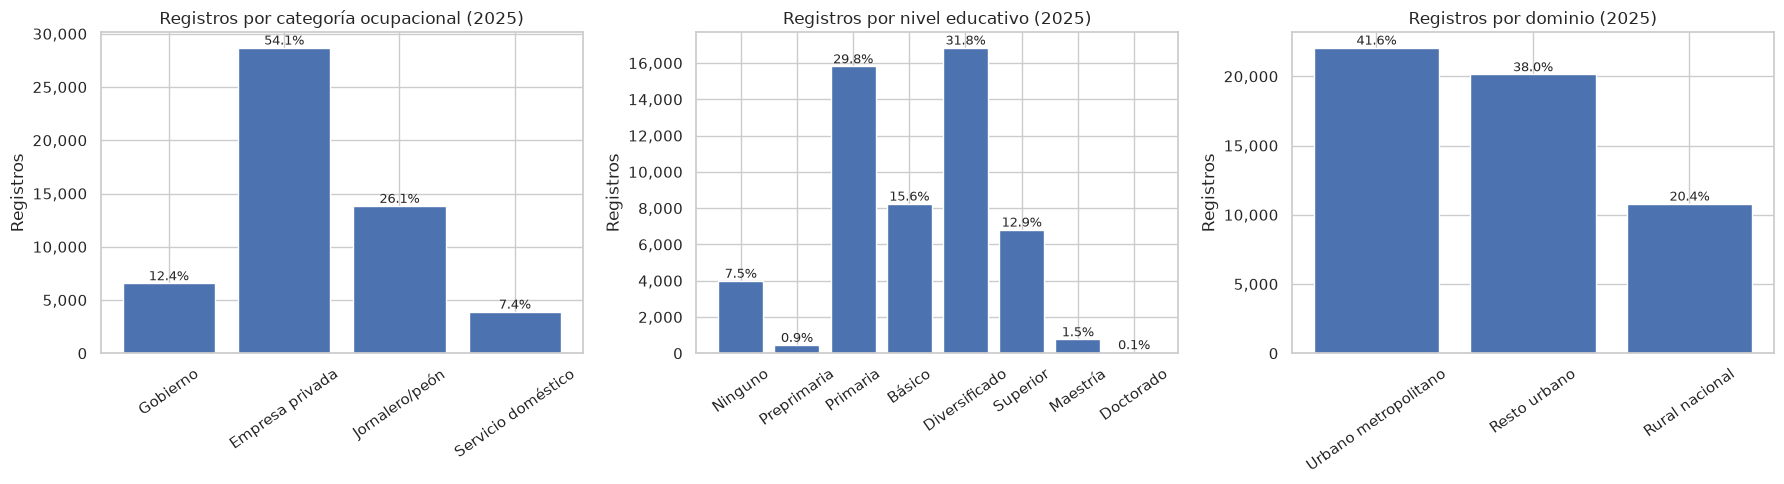

,registros,%
categoria_ocupacional,,
Gobierno,6575.0,12.4
Empresa privada,28702.0,54.1
Jornalero/peón,13842.0,26.1
Servicio doméstico,3906.0,7.4


,registros,%
nivel_educativo,,
Ninguno,3995.0,7.5
Preprimaria,459.0,0.9
Primaria,15822.0,29.8
Básico,8249.0,15.6
Diversificado,16851.0,31.8
Superior,6818.0,12.9
Maestría,771.0,1.5
Doctorado,60.0,0.1


,registros,%
dominio,,
Urbano metropolitano,22072.0,41.6
Resto urbano,20146.0,38.0
Rural nacional,10807.0,20.4


In [19]:
def conteo_cat(df, col, orden):
    pdf = df.groupBy(col).count().toPandas().set_index(col).reindex(orden).dropna()
    pdf["%"] = 100 * pdf["count"] / pdf["count"].sum()
    return pdf

tablas_cat = []
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, orden, titulo) in zip(axes, [("categoria_ocupacional", ORDEN_CAT, "Categoría ocupacional"),
                                          ("nivel_educativo", ORDEN_EDU, "Nivel educativo"),
                                          ("dominio", ORDEN_DOM, "Dominio")]):
    pdf = conteo_cat(df25, col, orden)
    bars = ax.bar(pdf.index, pdf["count"], color=sns.color_palette("deep")[0])
    for b, pct in zip(bars, pdf["%"]):
        ax.annotate(f"{pct:.1f}%", (b.get_x() + b.get_width() / 2, b.get_height()), ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Registros por {titulo.lower()} (2025)")
    ax.set_ylabel("Registros"); ax.tick_params(axis="x", rotation=35)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    tablas_cat.append(pdf.rename(columns={"count": "registros"}).round(1))
plt.tight_layout(); plt.show()
for t in tablas_cat: display(t)

**Interpretación.**
- **Categoría ocupacional:** más de la mitad de los registros (≈54%) son empleados de **empresa privada**; le siguen jornaleros/peones (≈26%), empleados de gobierno (≈12%) y servicio doméstico (≈7%). Los modelos tendrán mucha información sobre el sector privado y relativamente poca sobre servicio doméstico.
- **Nivel educativo:** la muestra se concentra en **diversificado (≈32%)** y **primaria (≈30%)**, seguidos de básico (≈16%) y superior (≈13%). Maestría (771 registros) y sobre todo doctorado (60) son grupos muy pequeños: cualquier estadística o error de predicción en esos grupos será inestable.
- **Dominio:** ≈42% urbano metropolitano, ≈38% resto urbano y ≈20% rural. El peso rural es bajo porque en el área rural predomina el trabajo por cuenta propia y agrícola, que queda fuera de la población asalariada.
- No quedó ningún registro en `DESCONOCIDO` para estas tres variables en la población filtrada.

## 2.2 ¿El salario presenta una distribución simétrica o asimétrica? ¿Qué diferencia existe entre su media y su mediana?

Histograma dibujado con una **muestra aleatoria de 10,000 registros** (sólo para graficar). La media, la mediana y los percentiles marcados provienen del conjunto **completo**.

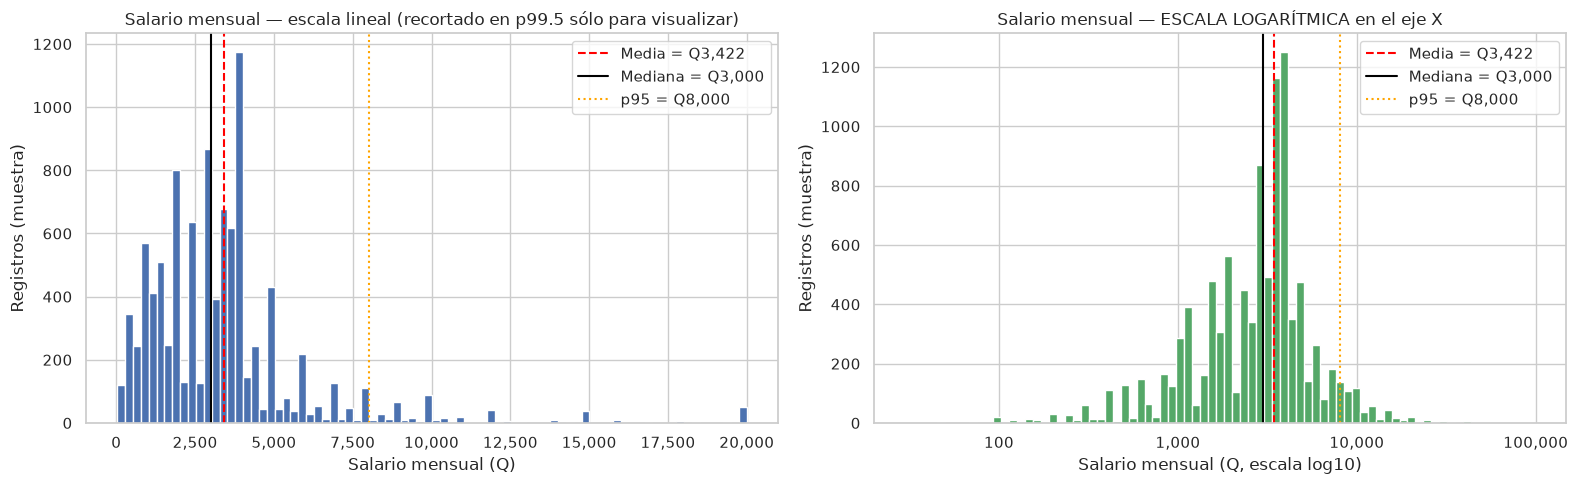

Media - mediana = Q421.68  (14.1% sobre la mediana)
Asimetría (Spark, datos completos) = 6.00


In [20]:
n25 = df25.count()
muestra_sal = (df25.sample(fraction=min(1.0, 12000 / n25), seed=SEED).limit(10000)
               .select("salario_mensual").toPandas())
media_sal, mediana_sal = desc25.loc["Salario mensual (Q)", ["media", "mediana"]]
p95_sal = desc25.loc["Salario mensual (Q)", "p95"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
ax.hist(muestra_sal["salario_mensual"].clip(upper=muestra_sal["salario_mensual"].quantile(0.995)), bins=80, color="#4C72B0")
ax.set_title("Salario mensual — escala lineal (recortado en p99.5 sólo para visualizar)")
ax.set_xlabel("Salario mensual (Q)")
ax2 = axes[1]
ax2.hist(muestra_sal["salario_mensual"], bins=np.logspace(np.log10(muestra_sal["salario_mensual"].min()),
                                                          np.log10(muestra_sal["salario_mensual"].max()), 80), color="#55A868")
ax2.set_xscale("log")
ax2.set_title("Salario mensual — ESCALA LOGARÍTMICA en el eje X")
ax2.set_xlabel("Salario mensual (Q, escala log10)")
for a in axes:
    a.axvline(media_sal, color="red", ls="--", label=f"Media = Q{media_sal:,.0f}")
    a.axvline(mediana_sal, color="black", ls="-", label=f"Mediana = Q{mediana_sal:,.0f}")
    a.axvline(p95_sal, color="orange", ls=":", label=f"p95 = Q{p95_sal:,.0f}")
    a.set_ylabel("Registros (muestra)"); a.legend()
    a.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

print(f"Media - mediana = Q{media_sal - mediana_sal:,.2f}  ({100 * (media_sal / mediana_sal - 1):.1f}% sobre la mediana)")
print(f"Asimetría (Spark, datos completos) = {desc25.loc['Salario mensual (Q)', 'asimetría']:.2f}")

**Interpretación.** El salario es claramente **asimétrico a la derecha** (asimetría ≈ 6.0 calculada en Spark sobre los 53,025 registros): la mayor parte de los salarios se concentra entre Q1,800 (p25) y Q4,000 (p75), pero hay una cola larga que llega hasta Q99,000 (el p95 es Q8,000, es decir, el 5% superior gana más del doble de la mediana). En escala lineal el histograma es una masa comprimida a la izquierda; en **escala logarítmica** (panel derecho, eje X en log10) la distribución se ve mucho más simétrica, lo que indica una forma aproximadamente log‑normal. También hay salarios anómalamente bajos (desde Q1; 22 registros de 2025 reportan menos de Q100), que se conservan porque cumplen el criterio (>0), pero que probablemente corresponden a pagos parciales o errores de captura.

**Media vs. mediana:** la media (≈ Q3,422) supera a la mediana (Q3,000) en ≈ Q422, un 14% más. La media es arrastrada por los salarios altos de la cola; la **mediana** es una medida más representativa del asalariado “típico”. Esto anticipa que en el modelado los errores cuadráticos (RMSE) estarán muy influidos por pocos salarios extremos. Conforme a las instrucciones, **no** se eliminan ni se transforman los salarios extremos para el modelado; el objetivo se mantiene en quetzales.

## 2.3 ¿Cómo varía el salario mediano entre niveles educativos y categorías ocupacionales?

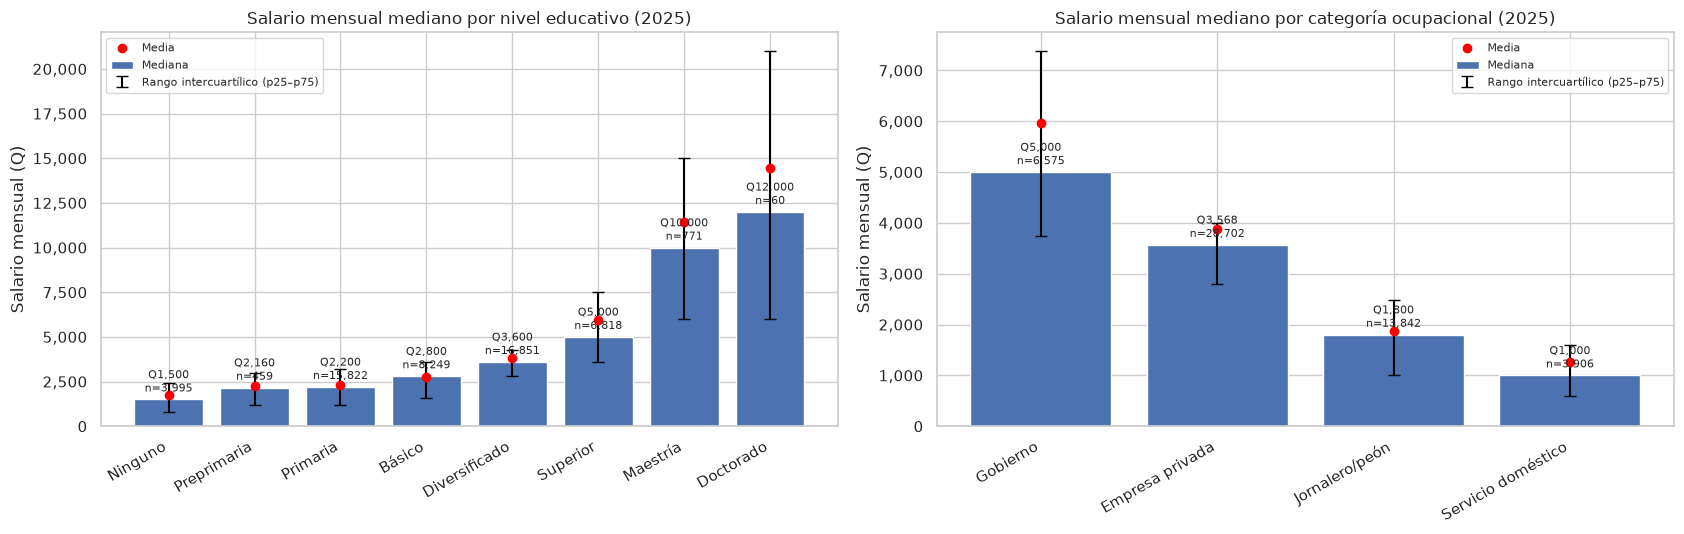

,n,mediana,p25,p75,media
nivel_educativo,,,,,
Ninguno,3995.0,1500.0,800.0,2400.0,1767.1
Preprimaria,459.0,2160.0,1200.0,3000.0,2241.9
Primaria,15822.0,2200.0,1200.0,3200.0,2308.0
Básico,8249.0,2800.0,1600.0,3600.0,2730.2
Diversificado,16851.0,3600.0,2800.0,4250.0,3796.4
Superior,6818.0,5000.0,3600.0,7500.0,5965.3
Maestría,771.0,10000.0,6000.0,15000.0,11409.3
Doctorado,60.0,12000.0,6000.0,21000.0,14452.3


,n,mediana,p25,p75,media
categoria_ocupacional,,,,,
Gobierno,6575.0,5000.0,3750.0,7380.0,5971.5
Empresa privada,28702.0,3567.5,2800.0,4000.0,3875.1
Jornalero/peón,13842.0,1800.0,1000.0,2489.8,1878.6
Servicio doméstico,3906.0,1000.0,600.0,1600.0,1265.7


In [21]:
def mediana_por(df, col, orden):
    pdf = (df.groupBy(col).agg(F.count("*").alias("n"),
                               F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                               F.expr("percentile(salario_mensual, 0.25)").alias("p25"),
                               F.expr("percentile(salario_mensual, 0.75)").alias("p75"),
                               F.mean("salario_mensual").alias("media"))
           .toPandas().set_index(col).reindex(orden).dropna())
    return pdf

med_edu = mediana_por(df25, "nivel_educativo", ORDEN_EDU)
med_cat = mediana_por(df25, "categoria_ocupacional", ORDEN_CAT)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
for ax, pdf, titulo in [(axes[0], med_edu, "nivel educativo"), (axes[1], med_cat, "categoría ocupacional")]:
    x = np.arange(len(pdf))
    ax.bar(x, pdf["mediana"], color="#4C72B0", label="Mediana")
    ax.errorbar(x, pdf["mediana"], yerr=[pdf["mediana"] - pdf["p25"], pdf["p75"] - pdf["mediana"]],
                fmt="none", ecolor="black", capsize=4, label="Rango intercuartílico (p25–p75)")
    ax.scatter(x, pdf["media"], color="red", zorder=3, label="Media")
    for xi, (m, n) in enumerate(zip(pdf["mediana"], pdf["n"])):
        ax.annotate(f"Q{m:,.0f}\nn={n:,.0f}", (xi, m), ha="center", va="bottom", fontsize=8, xytext=(0, 3), textcoords="offset points")
    ax.set_xticks(x); ax.set_xticklabels(pdf.index, rotation=30, ha="right")
    ax.set_title(f"Salario mensual mediano por {titulo} (2025)")
    ax.set_ylabel("Salario mensual (Q)"); ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()
display(med_edu.round(1)); display(med_cat.round(1))

**Interpretación.**
- **Educación:** el salario mediano crece de forma casi monótona con el nivel educativo: Q1,500 sin educación, ≈Q2,200 con primaria, Q2,800 con básico, Q3,600 con diversificado, Q5,000 con superior y Q10,000–12,000 con posgrado. El salto más fuerte ocurre a partir del nivel superior, y el rango intercuartílico también se ensancha con la educación (más dispersión salarial en los niveles altos). Maestría y doctorado tienen pocos registros, por lo que su mediana es menos precisa.
- **Categoría ocupacional:** los empleados de **gobierno** tienen la mediana más alta (Q5,000), seguidos de empresa privada (≈Q3,568), jornaleros/peones (Q1,800) y **servicio doméstico** (Q1,000). La brecha entre gobierno y servicio doméstico es de 5 a 1.
- En todas las categorías la media está por encima de la mediana, lo que confirma la asimetría dentro de cada grupo. Estas son **asociaciones**: parte de la diferencia por categoría refleja también diferencias de educación, edad y dominio entre grupos, no un efecto causal.

## 2.4 ¿Cómo cambian el tamaño de la muestra analítica y el salario mediano entre trimestres?

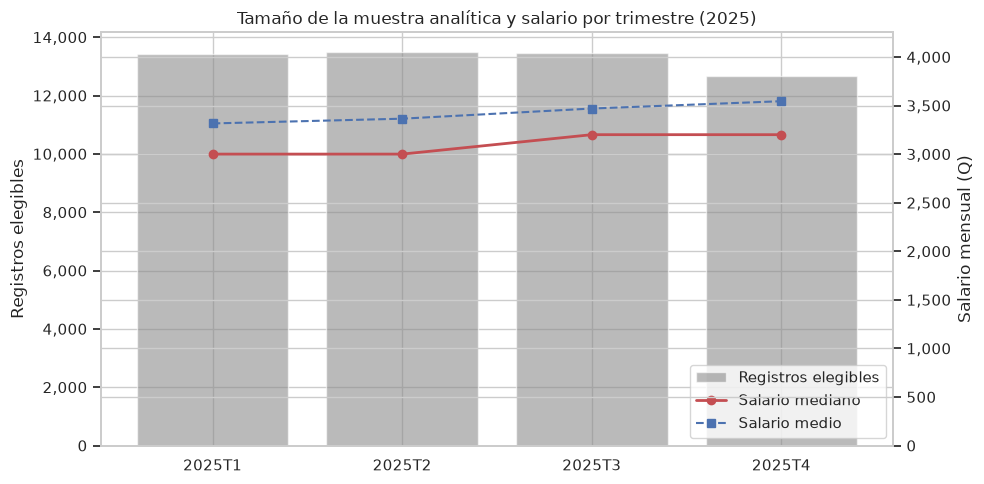

,n,mediana,media,registros originales,% elegible
periodo_archivo,,,,,
2025T1,13419,3000.0,3315.63,51588,26.01
2025T2,13492,3000.0,3364.57,51167,26.37
2025T3,13450,3200.0,3469.07,51583,26.07
2025T4,12664,3200.0,3544.57,49338,25.67


In [22]:
por_trim = (df25.groupBy("periodo_archivo").agg(F.count("*").alias("n"),
                                                F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                                                F.mean("salario_mensual").alias("media"))
            .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo"))
por_trim["registros originales"] = tabla.loc["Registros originales", por_trim.index].values
por_trim["% elegible"] = 100 * por_trim["n"] / por_trim["registros originales"]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(por_trim.index, por_trim["n"], color="#8C8C8C", alpha=0.6, label="Registros elegibles")
ax1.set_ylabel("Registros elegibles"); ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax2 = ax1.twinx()
ax2.plot(por_trim.index, por_trim["mediana"], marker="o", color="#C44E52", lw=2, label="Salario mediano")
ax2.plot(por_trim.index, por_trim["media"], marker="s", color="#4C72B0", lw=1.5, ls="--", label="Salario medio")
ax2.set_ylabel("Salario mensual (Q)"); ax2.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax2.set_ylim(0, por_trim["media"].max() * 1.2)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower right")
plt.title("Tamaño de la muestra analítica y salario por trimestre (2025)")
plt.tight_layout(); plt.show()
por_trim.round(2)

**Interpretación.** El tamaño de la muestra analítica es muy estable entre trimestres (≈13,400 registros en T1–T3 y 12,664 en T4, que también es el archivo con menos registros originales); en todos los casos se conserva ≈26% de los registros originales. El salario mediano pasa de Q3,000 en T1–T2 a Q3,200 en T3–T4 y la media sube gradualmente de ≈Q3,316 a ≈Q3,545: un aumento moderado a lo largo del año, sin cambios bruscos. Esto sugiere que es razonable entrenar con los cuatro trimestres de 2025 y evaluar en 2026T1, aunque una ligera tendencia al alza podría hacer que los modelos subestimen levemente los salarios de 2026. Recordatorio: los mismos hogares pueden aparecer en varios trimestres, por lo que los trimestres no son muestras independientes.

---
# 3. Relaciones entre variables numéricas

Correlación de **Pearson** con `VectorAssembler` + `pyspark.ml.stat.Correlation.corr()` sobre **todos** los registros elegibles de 2025.

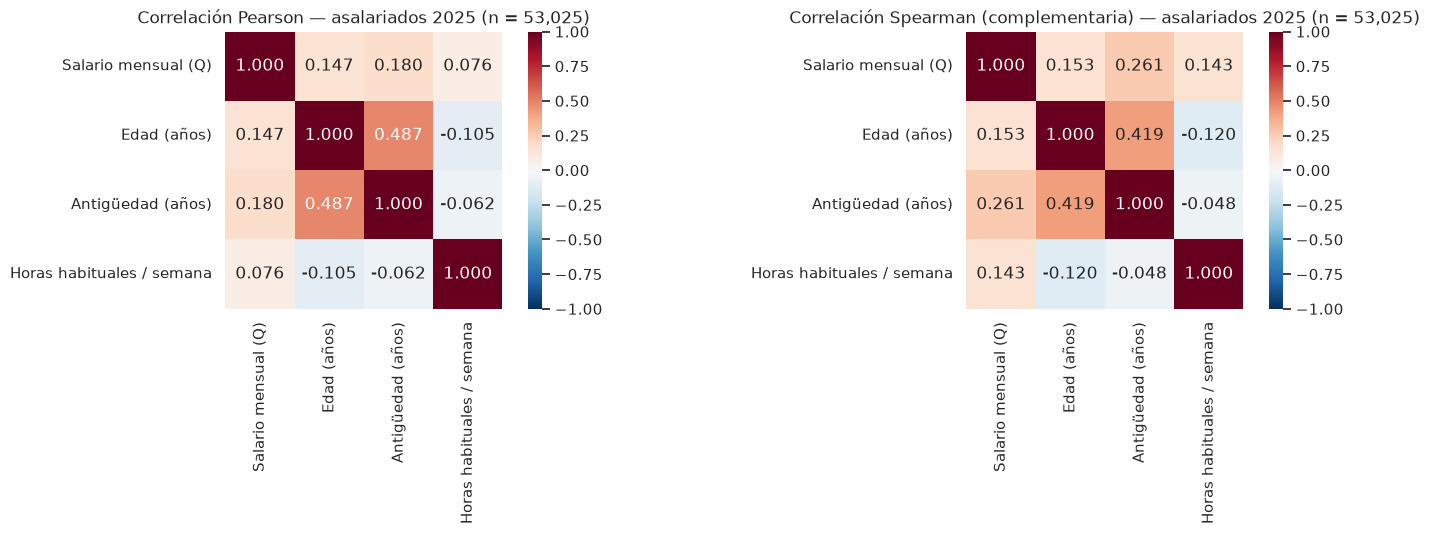

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.0000,0.1472,0.1796,0.0757
edad,0.1472,1.0000,0.4867,-0.1054
antiguedad,0.1796,0.4867,1.0000,-0.0623
horas_semanales,0.0757,-0.1054,-0.0623,1.0000


In [23]:
VARS_CORR = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
vec = VectorAssembler(inputCols=VARS_CORR, outputCol="vars").transform(df25).select("vars")
matriz = Correlation.corr(vec, "vars", method="pearson").first()[0].toArray()
corr_pd = pd.DataFrame(matriz, index=VARS_CORR, columns=VARS_CORR)

# Complemento: Spearman (por rangos), menos sensible a salarios extremos
matriz_s = Correlation.corr(vec, "vars", method="spearman").first()[0].toArray()
corr_s = pd.DataFrame(matriz_s, index=VARS_CORR, columns=VARS_CORR)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, m, t in [(axes[0], corr_pd, "Pearson"), (axes[1], corr_s, "Spearman (complementaria)")]:
    sns.heatmap(m, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
                xticklabels=[NUMERICAS[c] for c in VARS_CORR], yticklabels=[NUMERICAS[c] for c in VARS_CORR])
    ax.set_title(f"Correlación {t} — asalariados 2025 (n = {n25:,})")
plt.tight_layout(); plt.show()
corr_pd.round(4)

**Interpretación.**
- **Asociación lineal con el salario:** todas las correlaciones de Pearson con el salario son **débiles y positivas**. La mayor es con la **antigüedad (r ≈ 0.18)**, seguida de la **edad (r ≈ 0.15)**; las **horas habituales** casi no tienen asociación lineal (r ≈ 0.08). Ninguna variable numérica por sí sola explica mucho de la variación salarial (r² < 4%), lo que sugiere que las variables categóricas (educación, categoría ocupacional) y relaciones no lineales serán más importantes para predecir. Además, Pearson es sensible a los salarios extremos: la matriz de Spearman (por rangos), incluida como complemento, permite verificar si la asociación monótona es distinta cuando se reduce la influencia de la cola.
- **Edad y antigüedad:** sí existe una relación **positiva moderada (r ≈ 0.49)**, la más fuerte de la matriz. Es esperable: una persona sólo puede acumular antigüedad con el tiempo (la antigüedad está acotada por la edad). No es tan alta como para provocar multicolinealidad grave en la regresión, pero ambas variables comparten información.
- Las horas tienen una correlación ligeramente negativa con edad y antigüedad: los trabajadores más jóvenes tienden a reportar jornadas más largas.

---
# 4. Segmentación de perfiles mediante KMeans

**Variables de segmentación.** La pregunta de negocio busca perfiles según **edad, antigüedad y jornada habitual**, por lo que estas tres son la base. Se evalúan dos alternativas:

- **A (sin salario):** edad, antigüedad, horas semanales.
- **B (con salario):** las tres anteriores + `log(1 + salario)`. El salario entra en logaritmo porque, al ser muy asimétrico, un puñado de salarios extremos dominaría las distancias euclidianas aun después de estandarizar.

Todas las variables se **estandarizan** (`StandardScaler`, media 0 y desviación 1) porque KMeans usa distancias euclidianas y las escalas son muy distintas (años vs. horas vs. quetzales). Se prueba **K = 2, 3, 4, 5** con semilla fija y se evalúan:
- **Silueta** (`ClusteringEvaluator`, distancia euclidiana cuadrada): separación/cohesión, mayor es mejor.
- **WSSSE** (costo de entrenamiento): criterio del codo.

In [24]:
df_km = df25.withColumn("log_salario", F.log1p("salario_mensual")).cache()
VARIANTES = {
    "A: edad+antigüedad+horas": ["edad", "antiguedad", "horas_semanales"],
    "B: A + log(salario)": ["edad", "antiguedad", "horas_semanales", "log_salario"],
}

def preparar_km(df, cols):
    ens = VectorAssembler(inputCols=cols, outputCol="x").transform(df)
    esc = StandardScaler(inputCol="x", outputCol="features", withMean=True, withStd=True).fit(ens)
    return esc.transform(ens).cache(), esc

resultados, modelos, datos_km, escaladores = [], {}, {}, {}
for nombre, cols in VARIANTES.items():
    dfx, esc = preparar_km(df_km, cols)
    datos_km[nombre], escaladores[nombre] = dfx, esc
    for k in [2, 3, 4, 5]:
        m = KMeans(k=k, seed=SEED, featuresCol="features", predictionCol="cluster", maxIter=50).fit(dfx)
        pred = m.transform(dfx)
        sil = ClusteringEvaluator(featuresCol="features", predictionCol="cluster",
                                  metricName="silhouette", distanceMeasure="squaredEuclidean").evaluate(pred)
        tam = sorted(m.summary.clusterSizes)
        resultados.append({"variante": nombre, "K": k, "silueta": sil, "WSSSE": m.summary.trainingCost,
                           "cluster más pequeño (%)": 100 * tam[0] / sum(tam)})
        modelos[(nombre, k)] = m

res_km = pd.DataFrame(resultados)
res_km.round(4)

,variante,K,silueta,WSSSE,cluster más pequeño (%)
0,A: edad+antigüedad+horas,2,0.5547,106717.3861,27.5078
1,A: edad+antigüedad+horas,3,0.4195,84311.6151,14.3630
2,A: edad+antigüedad+horas,4,0.4760,64438.2080,12.9505
3,A: edad+antigüedad+horas,5,0.4912,56848.4469,4.9316
4,B: A + log(salario),2,0.4701,159172.6204,28.2735
5,B: A + log(salario),3,0.4747,125141.7465,17.7105
6,B: A + log(salario),4,0.4113,107383.3177,15.3230
7,B: A + log(salario),5,0.3333,96720.8014,12.1264


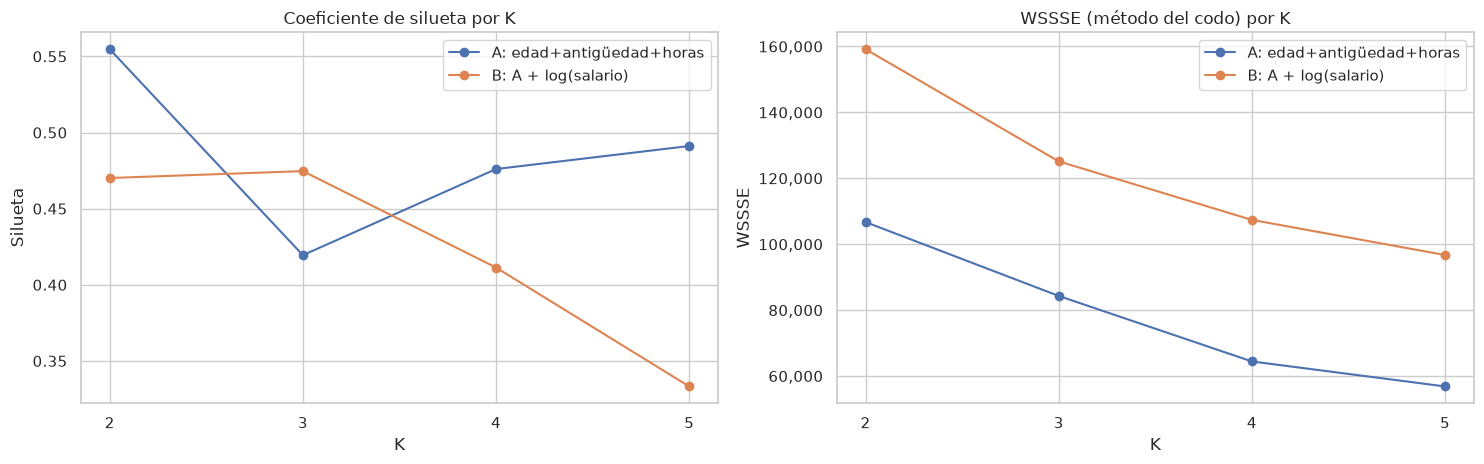

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for nombre, g in res_km.groupby("variante"):
    axes[0].plot(g["K"], g["silueta"], marker="o", label=nombre)
    axes[1].plot(g["K"], g["WSSSE"], marker="o", label=nombre)
axes[0].set_title("Coeficiente de silueta por K"); axes[0].set_xlabel("K"); axes[0].set_ylabel("Silueta")
axes[1].set_title("WSSSE (método del codo) por K"); axes[1].set_xlabel("K"); axes[1].set_ylabel("WSSSE")
for a in axes: a.set_xticks([2, 3, 4, 5]); a.legend()
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

**Elección de variables y de K.**

**¿Incluir el salario?** Se decidió **no incluirlo** (variante A):
1. Incluir el salario **no mejora la calidad de la segmentación de forma consistente**. La variante B sólo supera a la A en K = 3 (0.475 vs 0.420); en K = 2, 4 y 5 su silueta es menor y cae rápidamente al aumentar K (0.33 en K = 5). Su mejor valor (0.475, K = 3) es prácticamente igual al de la A con K = 4 (0.476). Además, en B el salario domina la partición: con K = 3 aparece un grupo definido por salario bajo y jornada parcial (salario mediano ≈ Q960, ≈ 26 h, mayoría de jornaleros y servicio doméstico). Eso repite lo que ya muestra el análisis descriptivo de la sección 2, en lugar de revelar perfiles laborales.
2. El salario es la **variable objetivo** del modelado supervisado. Construir perfiles *sin* el salario permite usarlo después como variable **descriptiva externa** para validar los perfiles (¿los perfiles difieren en salario sin haberlo usado para formarlos?), evitando un razonamiento circular.
3. La pregunta de negocio pide perfiles según edad, antigüedad y jornada.

**Elección de K = 4** (variante A). Criterios usados como grupo: silueta, codo del WSSSE, tamaño mínimo del cluster (≥ 10% para que sea un perfil útil) e interpretabilidad.
- K = 2 tiene la mayor silueta (0.55), pero sólo separa “jóvenes” de “mayores”, un perfil demasiado grueso.
- De K = 3 a K = 4 la silueta **sube** (0.42 → 0.48) y el WSSSE cae ≈ 19,900, mientras que de K = 4 a K = 5 la caída es sólo ≈ 7,600: el **codo está en K = 4**.
- K = 5 tiene silueta similar (0.49) pero genera un cluster de apenas 4.9% de los registros.
- K = 4 produce cuatro grupos con tamaño ≥ 13% y un significado claro (ver abajo).

In [26]:
VARIANTE_ELEGIDA = "A: edad+antigüedad+horas"
K_ELEGIDO = 4

modelo_km = modelos[(VARIANTE_ELEGIDA, K_ELEGIDO)]
seg = modelo_km.transform(datos_km[VARIANTE_ELEGIDA]).cache()

# Perfil numérico de cada cluster (conjunto completo)
perfil = (seg.groupBy("cluster").agg(
            F.count("*").alias("n"),
            F.round(F.mean("edad"), 1).alias("edad_media"),
            F.expr("percentile(edad, 0.5)").alias("edad_mediana"),
            F.round(F.mean("antiguedad"), 1).alias("antig_media"),
            F.expr("percentile(antiguedad, 0.5)").alias("antig_mediana"),
            F.round(F.mean("horas_semanales"), 1).alias("horas_media"),
            F.expr("percentile(horas_semanales, 0.5)").alias("horas_mediana"),
            F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
            F.round(F.mean("salario_mensual"), 0).alias("salario_medio"))
          .orderBy("cluster").toPandas().set_index("cluster"))
perfil.insert(1, "%", (100 * perfil["n"] / perfil["n"].sum()).round(1))
perfil

,n,%,edad_media,edad_mediana,antig_media,antig_mediana,horas_media,horas_mediana,salario_mediano,salario_medio
cluster,,,,,,,,,,
0,24488,46.2,25.8,26.0,2.4,1.25,40.9,44.0,3000.0,3075.0
1,12742,24.0,48.5,46.0,4.1,3.00,39.5,42.0,3000.0,3537.0
2,6867,13.0,49.9,48.0,22.2,20.00,41.1,40.0,3800.0,4681.0
3,8928,16.8,30.5,29.0,3.5,2.00,74.8,72.0,3000.0,3241.0


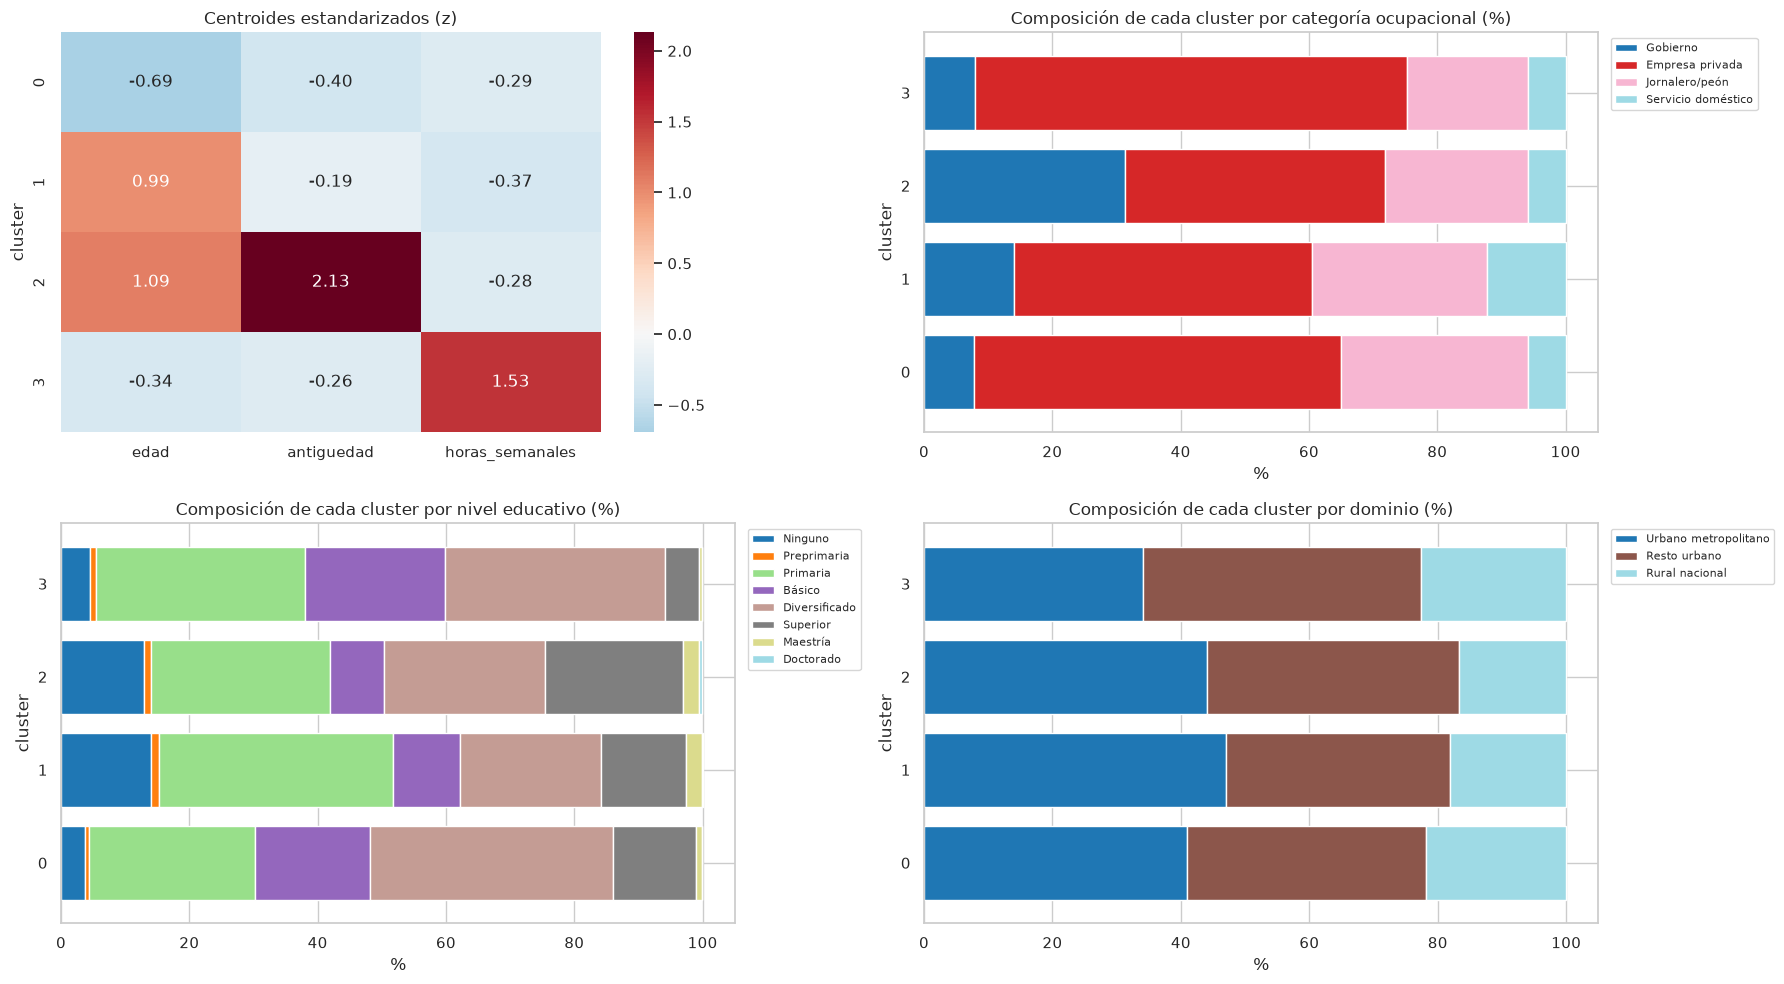

categoria_ocupacional,Gobierno,Empresa privada,Jornalero/peón,Servicio doméstico
cluster,,,,
0,7.8,57.2,29.2,5.8
1,14.1,46.4,27.3,12.3
2,31.4,40.5,22.3,5.9
3,8.0,67.3,18.9,5.8


nivel_educativo,Ninguno,Preprimaria,Primaria,Básico,Diversificado,Superior,Maestría,Doctorado
cluster,,,,,,,,
0,3.7,0.6,25.9,18.0,37.8,12.9,1.0,0.0
1,14.1,1.2,36.4,10.5,21.9,13.3,2.5,0.2
2,13.0,1.1,27.8,8.4,25.1,21.6,2.4,0.5
3,4.5,0.9,32.7,21.7,34.4,5.3,0.4,0.0


dominio,Urbano metropolitano,Resto urbano,Rural nacional
cluster,,,
0,40.9,37.3,21.8
1,47.0,34.9,18.0
2,44.1,39.2,16.7
3,34.1,43.3,22.6


In [27]:
# Centroides en unidades estandarizadas (z) — describen qué distingue a cada cluster
cols_sel = VARIANTES[VARIANTE_ELEGIDA]
centros = pd.DataFrame(modelo_km.clusterCenters(), columns=cols_sel)
centros.index.name = "cluster"

def composicion(col, orden):
    pdf = (seg.groupBy("cluster", col).count().toPandas()
           .pivot(index="cluster", columns=col, values="count").fillna(0))
    pdf = pdf[[c for c in orden if c in pdf.columns]]
    return (100 * pdf.div(pdf.sum(axis=1), axis=0)).round(1)

comp_cat = composicion("categoria_ocupacional", ORDEN_CAT)
comp_edu = composicion("nivel_educativo", ORDEN_EDU)
comp_dom = composicion("dominio", ORDEN_DOM)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
sns.heatmap(centros, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0, 0])
axes[0, 0].set_title("Centroides estandarizados (z)")
for ax, comp, t in [(axes[0, 1], comp_cat, "categoría ocupacional"), (axes[1, 0], comp_edu, "nivel educativo"),
                    (axes[1, 1], comp_dom, "dominio")]:
    comp.plot(kind="barh", stacked=True, ax=ax, colormap="tab20", width=0.8)
    ax.set_title(f"Composición de cada cluster por {t} (%)"); ax.set_xlabel("%")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()
display(comp_cat); display(comp_edu); display(comp_dom)

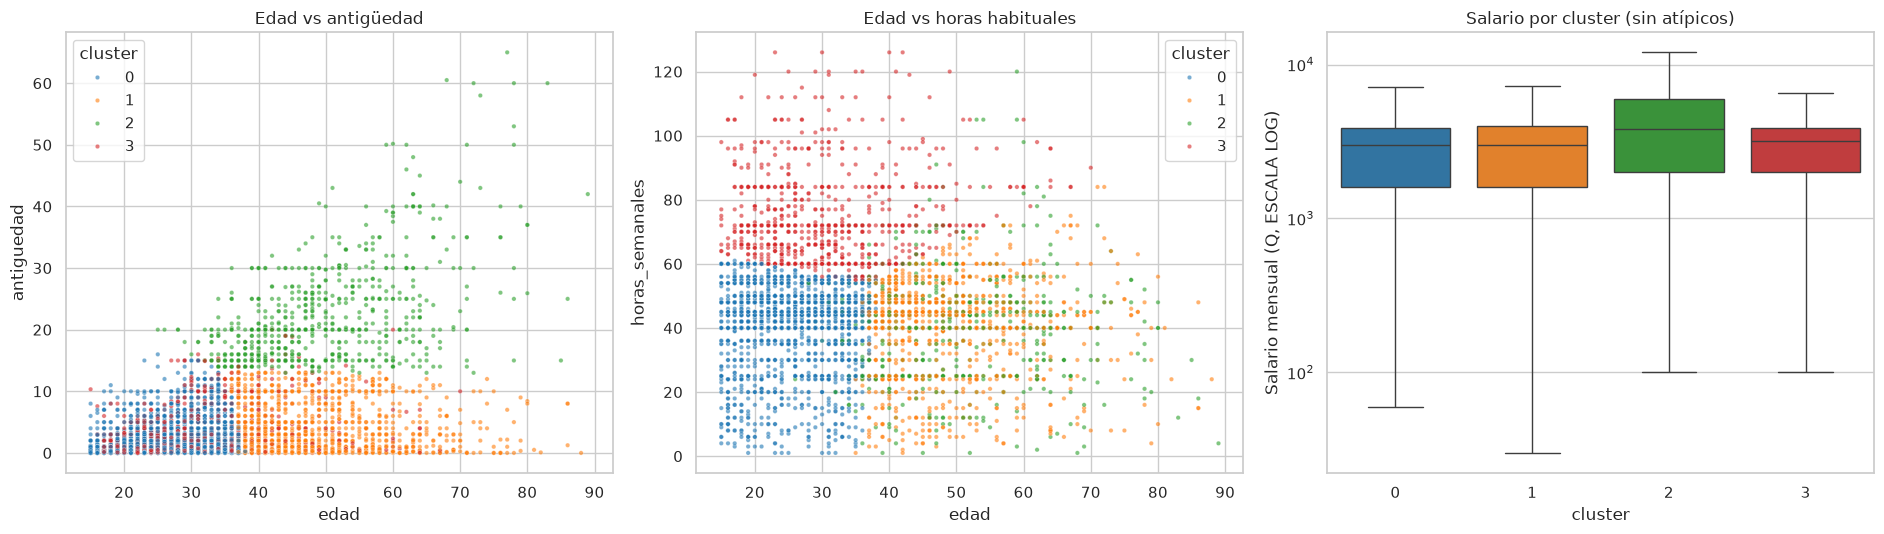

In [28]:
# Visualización con una muestra de 5,000 registros (sólo para graficar)
muestra_seg = (seg.sample(fraction=min(1.0, 6000 / n25), seed=SEED).limit(5000)
               .select("cluster", "edad", "antiguedad", "horas_semanales", "salario_mensual").toPandas())
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
pal = sns.color_palette("tab10", K_ELEGIDO)
sns.scatterplot(data=muestra_seg, x="edad", y="antiguedad", hue="cluster", palette=pal, s=10, alpha=0.6, ax=axes[0])
sns.scatterplot(data=muestra_seg, x="edad", y="horas_semanales", hue="cluster", palette=pal, s=10, alpha=0.6, ax=axes[1])
sns.boxplot(data=muestra_seg, x="cluster", y="salario_mensual", hue="cluster", palette=pal, ax=axes[2], legend=False, showfliers=False)
axes[2].set_yscale("log"); axes[2].set_ylabel("Salario mensual (Q, ESCALA LOG)")
axes[0].set_title("Edad vs antigüedad"); axes[1].set_title("Edad vs horas habituales"); axes[2].set_title("Salario por cluster (sin atípicos)")
plt.tight_layout(); plt.show()

### Descripción de los perfiles (K = 4, variables: edad, antigüedad y horas)

| Cluster | Nombre | Tamaño | Rasgos principales |
|---|---|---|---|
| 0 | **Jóvenes de inserción reciente** | ≈ 46% | Edad media ≈ 26 años, antigüedad ≈ 2.4 años, jornada estándar (~41 h). Salario mediano ≈ Q3,000. Mayoría en empresa privada (57%) y la mayor proporción de jornaleros (29%); predomina diversificado (38%), seguido de primaria y básico. |
| 1 | **Adultos maduros con poca antigüedad** | ≈ 24% | Edad ≈ 48 años pero sólo ≈ 4 años en su empleo actual y jornada estándar o parcial (~40 h). Salario mediano ≈ Q3,000. Tiene la mayor proporción de servicio doméstico (12%), de personas sin educación (14%) y de primaria (36%). Su salario medio (≈ Q3,540) supera la mediana, porque combina trabajadores de baja calificación con algunos profesionales. Sugiere trayectorias con rotación o reinserción laboral. |
| 2 | **Veteranos estables** | ≈ 13% | Edad ≈ 50 años y antigüedad muy alta (≈ 22 años), jornada estándar. Tienen el **salario mediano más alto** (≈ Q3,800), ≈ 31% son empleados de gobierno y ≈ 25% tienen educación superior o más: perfil de empleo formal y estable. |
| 3 | **Jornadas extensas** | ≈ 17% | Adultos jóvenes (≈ 30 años) con poca antigüedad que trabajan **≈ 75 horas semanales**. Su salario mediano (≈ Q3,000) es igual al de los jóvenes con jornada estándar, por lo que su **salario por hora es mucho menor**. Es el grupo con más empleo en empresa privada (67%) y menos educación superior (≈ 6%). |

**Conclusiones de la segmentación.**
- La antigüedad es la variable que mejor diferencia salarialmente a los perfiles: sólo los *veteranos estables* muestran un salario mediano claramente superior, lo que es coherente con la correlación positiva (aunque débil) entre antigüedad y salario.
- Trabajar más horas **no** se traduce en mayor salario mensual (cluster 3), consistente con la correlación casi nula entre horas y salario.
- La silueta (~0.48) indica una estructura de grupos moderada: los perfiles son útiles para describir, pero las fronteras entre ellos no son nítidas (edad y antigüedad forman un continuo).
- Las etiquetas de cluster **no** se usarán como predictores en los modelos supervisados, conforme a las instrucciones.

---
# MODELADO SUPERVISADO

## Diseño de la evaluación

| Conjunto | Datos | Uso |
|---|---|---|
| **Entrenamiento** | 2025T1, 2025T2, 2025T3 | Ajustar *todas* las etapas del pipeline (indexadores, codificadores, modelo) |
| **Validación** | 2025T4 | Comparar configuraciones y elegir la de menor RMSE |
| **Entrenamiento final** | 2025T1–T4 | Re‑ajustar la configuración elegida de cada algoritmo |
| **Prueba** | 2026T1 | Evaluación final única (actividad 7) |

La validación es **temporal** (el trimestre más reciente de 2025), lo que imita el uso real: entrenar con el pasado y predecir un período posterior. Una misma persona puede aparecer en T1–T3 y en T4 (panel rotativo), por lo que la validación es algo optimista; la prueba en 2026 es el indicador más honesto.

**Predictores (exactamente seis):** `edad`, `antiguedad`, `horas_semanales` (numéricos) y `nivel_educativo`, `categoria_ocupacional`, `dominio` (categóricos). **Objetivo:** `salario_mensual` en quetzales, sin transformar y sin recortar extremos.

**Modelo de referencia:** predecir para todos la **media del salario de entrenamiento**. Es el punto de comparación mínimo: su R² es ≈ 0 por construcción, por lo que cualquier modelo útil debe superarlo.

**Métricas:** MAE (error absoluto medio en Q), RMSE (penaliza más los errores grandes), R² (proporción de varianza explicada) y, como complemento, el **error medio** (media del residuo = real − predicho; positivo ⇒ el modelo subestima en promedio).

In [29]:
seg.unpersist(); df_km.unpersist()

CATEG = ["nivel_educativo", "categoria_ocupacional", "dominio"]
NUM = ["edad", "antiguedad", "horas_semanales"]
OBJ = "salario_mensual"
MODEL_DIR = "modelos"
os.makedirs(MODEL_DIR, exist_ok=True)

train = df25.filter(F.col("periodo_archivo").isin("2025T1", "2025T2", "2025T3")).cache()
val = df25.filter(F.col("periodo_archivo") == "2025T4").cache()
print(f"Entrenamiento (2025T1–T3): {train.count():,} | Validación (2025T4): {val.count():,} | Prueba (2026T1): {df26.count():,}")

# Los códigos ausentes o no reconocidos ya se convirtieron a la categoría explícita "DESCONOCIDO" en la
# preparación, así que el StringIndexer siempre ve un conjunto de etiquetas estable. Se verifica que
# validación y prueba no contengan categorías que no existan en entrenamiento.
for c in CATEG:
    vistas = {r[0] for r in train.select(c).distinct().collect()}
    for nombre_df, d in [("validación", val), ("prueba", df26)]:
        nuevas = {r[0] for r in d.select(c).distinct().collect()} - vistas
        assert not nuevas, f"{c}: categorías no vistas en entrenamiento en {nombre_df}: {nuevas}"
print("Validación y prueba sólo contienen categorías vistas en entrenamiento.")

def etapas_features():
    # a) StringIndexer + OneHotEncoder para las categóricas; b) VectorAssembler con numéricas + codificadas.
    # frequencyAsc + dropLast=True => se omite la categoría MÁS frecuente, que queda como referencia
    # de la regresión lineal (evita la colinealidad perfecta de las dummies con el intercepto).
    idx_cols = [f"{c}_idx" for c in CATEG]
    ohe_cols = [f"{c}_ohe" for c in CATEG]
    return [StringIndexer(inputCols=CATEG, outputCols=idx_cols, handleInvalid="error", stringOrderType="frequencyAsc"),
            OneHotEncoder(inputCols=idx_cols, outputCols=ohe_cols, dropLast=True),
            VectorAssembler(inputCols=NUM + ohe_cols, outputCol="features")]

EVALUADORES = {m: RegressionEvaluator(labelCol=OBJ, predictionCol="prediction", metricName=m) for m in ["mae", "rmse", "r2"]}

def metricas(pred):
    r = {"MAE": EVALUADORES["mae"].evaluate(pred), "RMSE": EVALUADORES["rmse"].evaluate(pred),
         "R²": EVALUADORES["r2"].evaluate(pred)}
    r["Error medio"] = pred.agg(F.mean(F.col(OBJ) - F.col("prediction"))).first()[0]
    return r

def pred_referencia(df, valor):
    return df.withColumn("prediction", F.lit(float(valor)))

media_train = train.agg(F.mean(OBJ)).first()[0]
ref_val = metricas(pred_referencia(val, media_train))
print(f"Media de entrenamiento = Q{media_train:,.2f}")
pd.DataFrame({"Referencia (media) — validación": ref_val}).T.round(3)

Entrenamiento (2025T1–T3): 40,361 | Validación (2025T4): 12,664 | Prueba (2026T1): 13,258


Validación y prueba sólo contienen categorías vistas en entrenamiento.


Media de entrenamiento = Q3,383.12


,MAE,RMSE,R²,Error medio
Referencia (media) — validación,1672.503,2889.571,-0.003,161.45


## 5. Pipeline de regresión lineal

Etapas: `StringIndexer` → `OneHotEncoder` → `VectorAssembler` → `LinearRegression(standardization=True)`.

La estandarización se hace con la **opción interna** de `LinearRegression` (`standardization=True`): Spark escala los predictores internamente para que la penalización trate por igual a todas las variables, pero devuelve los coeficientes en la escala original (quetzales por unidad). Por eso no se agrega `StandardScaler`.

**Configuraciones de regularización probadas** (`regParam` = λ, `elasticNetParam` = α; α = 0 es Ridge/L2, α = 1 es Lasso/L1). Como el objetivo está en quetzales, λ se explora en varios órdenes de magnitud:

In [30]:
CONFIG_LR = [
    {"nombre": "OLS (sin regularización)", "regParam": 0.0,   "elasticNetParam": 0.0},
    {"nombre": "Ridge λ=10",               "regParam": 10.0,  "elasticNetParam": 0.0},
    {"nombre": "Ridge λ=100",              "regParam": 100.0, "elasticNetParam": 0.0},
    {"nombre": "Lasso λ=10",               "regParam": 10.0,  "elasticNetParam": 1.0},
    {"nombre": "Elastic Net λ=50, α=0.5",  "regParam": 50.0,  "elasticNetParam": 0.5},
]

def pipeline_lr(cfg):
    lr = LinearRegression(featuresCol="features", labelCol=OBJ, predictionCol="prediction",
                          regParam=cfg["regParam"], elasticNetParam=cfg["elasticNetParam"],
                          standardization=True, maxIter=200)
    return Pipeline(stages=etapas_features() + [lr])

filas, modelos_lr = [], {}
for cfg in CONFIG_LR:
    m = pipeline_lr(cfg).fit(train)                    # todas las etapas se ajustan SOLO con entrenamiento
    modelos_lr[cfg["nombre"]] = m
    mt, mv = metricas(m.transform(train)), metricas(m.transform(val))
    filas.append({"configuración": cfg["nombre"], "regParam": cfg["regParam"], "elasticNetParam": cfg["elasticNetParam"],
                  "MAE train": mt["MAE"], "RMSE train": mt["RMSE"], "R² train": mt["R²"],
                  "MAE val": mv["MAE"], "RMSE val": mv["RMSE"], "R² val": mv["R²"], "Error medio val": mv["Error medio"]})
res_lr = pd.DataFrame(filas).set_index("configuración")
mejor_lr_nombre = res_lr["RMSE val"].idxmin()
CFG_LR = next(c for c in CONFIG_LR if c["nombre"] == mejor_lr_nombre)
print("Mejor configuración LR (menor RMSE de validación):", mejor_lr_nombre)
res_lr.round(3)

Mejor configuración LR (menor RMSE de validación): OLS (sin regularización)


,regParam,elasticNetParam,MAE train,RMSE train,R² train,MAE val,RMSE val,R² val,Error medio val
configuración,,,,,,,,,
OLS (sin regularización),0.0,0.0,1237.790,2245.293,0.403,1210.137,2186.420,0.426,111.496
Ridge λ=10,10.0,0.0,1237.358,2245.297,0.403,1209.627,2186.563,0.426,111.531
Ridge λ=100,100.0,0.0,1233.898,2245.708,0.403,1205.557,2188.187,0.425,111.873
Lasso λ=10,10.0,1.0,1234.067,2245.576,0.403,1205.632,2187.449,0.425,111.443
"Elastic Net λ=50, α=0.5",50.0,0.5,1229.266,2247.411,0.402,1199.880,2190.745,0.423,111.512


In [31]:
mejor_lr = modelos_lr[mejor_lr_nombre]
mejor_lr.write().overwrite().save(f"{MODEL_DIR}/lr_mejor_validacion")

val_lr = metricas(mejor_lr.transform(val))
pd.DataFrame({"Referencia (media)": ref_val, f"Regresión lineal — {mejor_lr_nombre}": val_lr}).T.round(3)

,MAE,RMSE,R²,Error medio
Referencia (media),1672.503,2889.571,-0.003,161.450
Regresión lineal — OLS (sin regularización),1210.137,2186.420,0.426,111.496


In [32]:
def nombres_features(modelo, df):
    meta = modelo.transform(df.limit(1)).schema["features"].metadata["ml_attr"]["attrs"]
    attrs = sorted([a for grupo in meta.values() for a in grupo], key=lambda a: a["idx"])
    return [a["name"] for a in attrs]

nombres = nombres_features(mejor_lr, train)
lr_stage = mejor_lr.stages[-1]
coef = pd.DataFrame({"variable": nombres, "coeficiente (Q)": lr_stage.coefficients.toArray()})
print(f"Intercepto: Q{lr_stage.intercept:,.2f}")
print("Categorías de referencia (omitidas por dropLast=True, las más frecuentes):",
      {c: lbls[-1] for c, lbls in zip(CATEG, mejor_lr.stages[0].labelsArray)})
coef.sort_values("coeficiente (Q)", key=np.abs, ascending=False).round(2)

Intercepto: Q2,457.97
Categorías de referencia (omitidas por dropLast=True, las más frecuentes): {'nivel_educativo': 'Diversificado', 'categoria_ocupacional': 'Empresa privada', 'dominio': 'Urbano metropolitano'}


,variable,coeficiente (Q)
3,nivel_educativo_ohe_Doctorado,8619.70
5,nivel_educativo_ohe_Maestría,6780.56
7,nivel_educativo_ohe_Superior,1694.39
10,categoria_ocupacional_ohe_Servicio doméstico,-1664.57
6,nivel_educativo_ohe_Ninguno,-1333.40
11,categoria_ocupacional_ohe_Gobierno,1173.60
4,nivel_educativo_ohe_Preprimaria,-1049.07
12,categoria_ocupacional_ohe_Jornalero/peón,-858.48
9,nivel_educativo_ohe_Primaria,-836.43
8,nivel_educativo_ohe_Básico,-631.22


**Interpretación — regresión lineal.**

- **Selección:** las cinco configuraciones dan prácticamente el mismo resultado: el RMSE de validación va de Q2,186 a Q2,191. La de menor RMSE es **OLS sin regularización** (λ = 0), que es la seleccionada. La regularización casi no cambia nada porque el modelo tiene sólo 15 coeficientes y ≈ 40,000 registros de entrenamiento, así que **no hay sobreajuste que corregir**: el R² de entrenamiento (0.403) incluso es menor que el de validación (0.426). Ridge, Lasso y Elastic Net sólo encogen un poco los coeficientes y bajan levemente el MAE, a costa de un RMSE ligeramente mayor.
- **Frente al modelo de referencia (validación 2025T4):** la regresión lineal reduce el MAE de Q1,673 a **Q1,210** (−28%) y el RMSE de Q2,890 a **Q2,186** (−24%). Explica ≈ **43% de la varianza** del salario, mientras que la referencia explica 0%. Es una mejora sustancial, pero todavía un error típico de ≈ Q1,200 por persona, más de un tercio de la mediana salarial (Q3,000).
- **Error medio positivo (≈ +Q111):** en validación el modelo subestima en promedio. Esto es coherente con el ligero aumento de salarios de T1–T3 a T4 visto en la sección 2.4.
- **Coeficientes** (en quetzales, manteniendo lo demás constante; referencia = diversificado, empresa privada, urbano metropolitano). La educación es lo que más pesa: +Q1,694 por educación superior, +Q6,781 por maestría y +Q8,620 por doctorado frente a diversificado, y −Q1,333 sin ninguna educación. Por categoría: gobierno +Q1,174, jornalero −Q858, servicio doméstico −Q1,665. Por dominio: rural y resto urbano ≈ −Q560 frente al área metropolitana. Cada año de edad suma ≈ Q20, cada año de antigüedad ≈ Q23 y cada hora semanal ≈ Q16. Son **asociaciones condicionales, no efectos causales**.
- **Limitación estructural:** el modelo es aditivo y lineal. No puede capturar interacciones (p. ej. que el premio a la educación sea distinto en gobierno que en servicio doméstico) ni efectos no lineales de horas o edad, y puede producir predicciones negativas para perfiles de muy bajo salario.

## 6. Pipeline de Random Forest

Etapas: `StringIndexer` → `OneHotEncoder` → `VectorAssembler` → `RandomForestRegressor` (sin estandarización: los árboles dividen por umbrales y son invariantes a la escala). Se usan los **mismos** conjuntos de entrenamiento (2025T1–T3) y validación (2025T4) y una **semilla fija**.

**Configuraciones probadas** (número de árboles y profundidad máxima):

In [33]:
CONFIG_RF = [
    {"nombre": "RF 50 árboles, prof. 5",   "numTrees": 50,  "maxDepth": 5},
    {"nombre": "RF 100 árboles, prof. 8",  "numTrees": 100, "maxDepth": 8},
    {"nombre": "RF 100 árboles, prof. 12", "numTrees": 100, "maxDepth": 12},
    {"nombre": "RF 200 árboles, prof. 12", "numTrees": 200, "maxDepth": 12},
]

def pipeline_rf(cfg):
    rf = RandomForestRegressor(featuresCol="features", labelCol=OBJ, predictionCol="prediction",
                               numTrees=cfg["numTrees"], maxDepth=cfg["maxDepth"], seed=SEED)
    return Pipeline(stages=etapas_features() + [rf])

filas, modelos_rf = [], {}
for cfg in CONFIG_RF:
    t0 = time.time()
    m = pipeline_rf(cfg).fit(train)
    modelos_rf[cfg["nombre"]] = m
    mt, mv = metricas(m.transform(train)), metricas(m.transform(val))
    filas.append({"configuración": cfg["nombre"], "numTrees": cfg["numTrees"], "maxDepth": cfg["maxDepth"],
                  "MAE train": mt["MAE"], "RMSE train": mt["RMSE"], "R² train": mt["R²"],
                  "MAE val": mv["MAE"], "RMSE val": mv["RMSE"], "R² val": mv["R²"], "Error medio val": mv["Error medio"],
                  "segundos": round(time.time() - t0, 1)})
res_rf = pd.DataFrame(filas).set_index("configuración")
mejor_rf_nombre = res_rf["RMSE val"].idxmin()
CFG_RF = next(c for c in CONFIG_RF if c["nombre"] == mejor_rf_nombre)
print("Mejor configuración RF (menor RMSE de validación):", mejor_rf_nombre)
res_rf.round(3)

Mejor configuración RF (menor RMSE de validación): RF 100 árboles, prof. 12


,numTrees,maxDepth,MAE train,RMSE train,R² train,MAE val,RMSE val,R² val,Error medio val,segundos
configuración,,,,,,,,,,
"RF 50 árboles, prof. 5",50,5,1207.727,2222.048,0.415,1190.970,2181.506,0.428,105.043,1.6
"RF 100 árboles, prof. 8",100,8,1118.819,2055.620,0.500,1112.412,2053.536,0.493,94.322,3.1
"RF 100 árboles, prof. 12",100,12,1043.091,1871.687,0.585,1064.304,1971.297,0.533,97.151,10.5
"RF 200 árboles, prof. 12",200,12,1042.792,1882.492,0.580,1065.004,1973.895,0.532,97.747,24.2


,MAE,RMSE,R²,Error medio
Referencia (media),1672.503,2889.571,-0.003,161.450
Regresión lineal — OLS (sin regularización),1210.137,2186.420,0.426,111.496
"Random Forest — RF 100 árboles, prof. 12",1064.304,1971.297,0.533,97.151


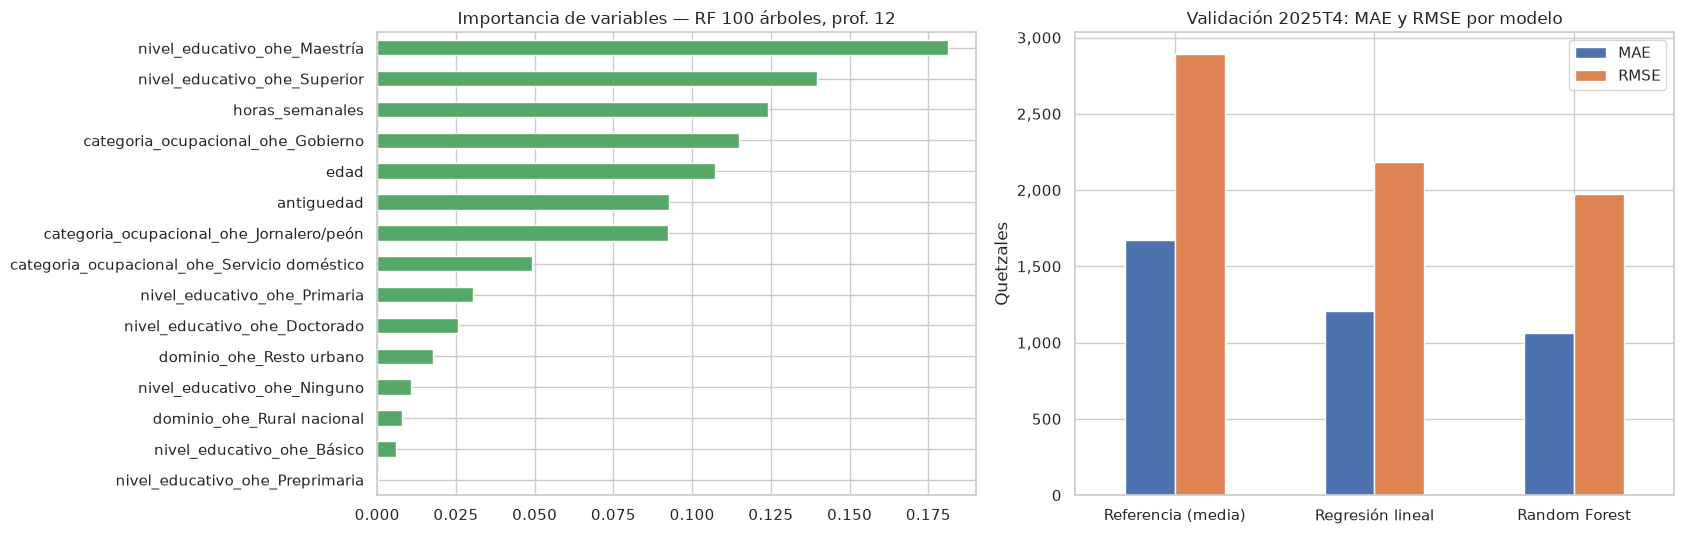

,importancia
nivel_educativo_ohe_Maestría,0.1811
nivel_educativo_ohe_Superior,0.1395
horas_semanales,0.1242
categoria_ocupacional_ohe_Gobierno,0.1148
edad,0.1073
antiguedad,0.0927
categoria_ocupacional_ohe_Jornalero/peón,0.0923
categoria_ocupacional_ohe_Servicio doméstico,0.0493
nivel_educativo_ohe_Primaria,0.0305
nivel_educativo_ohe_Doctorado,0.0255


In [34]:
mejor_rf = modelos_rf[mejor_rf_nombre]
mejor_rf.write().overwrite().save(f"{MODEL_DIR}/rf_mejor_validacion")

val_rf = metricas(mejor_rf.transform(val))
comp_val = pd.DataFrame({"Referencia (media)": ref_val,
                         f"Regresión lineal — {mejor_lr_nombre}": val_lr,
                         f"Random Forest — {mejor_rf_nombre}": val_rf}).T
display(comp_val.round(3))

imp = pd.Series(mejor_rf.stages[-1].featureImportances.toArray(), index=nombres_features(mejor_rf, train))
fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
imp.sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title(f"Importancia de variables — {mejor_rf_nombre}")
comp_val[["MAE", "RMSE"]].plot(kind="bar", ax=axes[1], rot=0)
axes[1].set_title("Validación 2025T4: MAE y RMSE por modelo"); axes[1].set_ylabel("Quetzales")
axes[1].set_xticklabels([t.split(" — ")[0] for t in comp_val.index])
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4).to_frame("importancia")

**Interpretación — Random Forest.**

- **Selección:** la **profundidad** es lo que más importa. Pasar de profundidad 5 a 8 y a 12 baja el RMSE de validación de Q2,182 a Q2,054 y a **Q1,971**. Duplicar el número de árboles (100 → 200) con profundidad 12 no mejora nada (Q1,974), porque con 100 árboles el promedio del bosque ya es estable. Se selecciona **100 árboles, profundidad 12**, que además entrena en la mitad del tiempo. Aparece un sobreajuste moderado: R² de 0.585 en entrenamiento frente a 0.533 en validación. Aun así, esta es la configuración que mejor generaliza entre las probadas.
- **Comparación en validación:**

  | Modelo | MAE | RMSE | R² |
  |---|---|---|---|
  | Referencia (media) | 1,673 | 2,890 | 0.00 |
  | Regresión lineal | 1,210 | 2,186 | 0.43 |
  | **Random Forest** | **1,064** | **1,971** | **0.53** |

  El **Random Forest es el mejor algoritmo en validación**: reduce el MAE ≈ 12% y el RMSE ≈ 10% respecto a la regresión lineal, y explica ≈ 11 puntos porcentuales más de varianza.
- **¿Por qué?** El salario depende de los predictores de forma **no lineal y con interacciones**, y los árboles las capturan sin especificarlas. Por ejemplo, las **horas semanales** son la 3.ª variable más importante del bosque, mientras que su coeficiente lineal es pequeño (Q16/hora): el efecto de las horas es distinto para jornadas parciales, completas o extensas, y depende de la categoría ocupacional. El bosque también combina edad, antigüedad y educación de forma flexible, y sus predicciones siempre quedan dentro del rango observado (nunca son negativas). La regresión lineal, en cambio, impone el mismo efecto aditivo para todos. Sus ventajas son otras: coeficientes interpretables, rapidez y menor riesgo de sobreajuste.
- **Importancia de variables (RF):** maestría, educación superior, horas, gobierno, edad y antigüedad son las más relevantes. El dominio aporta poco una vez que se conocen la educación y la categoría ocupacional.

## 7. Entrenamiento final y evaluación en 2026T1

1. Con la configuración elegida de cada algoritmo, se **re‑ajusta el pipeline completo con los cuatro trimestres de 2025** (el IV trimestre se usó para validar y ahora se incorpora al entrenamiento final, como indica la tabla de uso de los datos).
2. Los datos de 2026T1 ya pasaron por **exactamente las mismas reglas de preparación** (sección 1: mismas funciones de homologación, etiquetas y filtros en el mismo orden).
3. Ambos modelos se evalúan sobre **los mismos registros elegibles** de prueba; se verifica uniendo las predicciones por la clave.

In [35]:
final_lr = pipeline_lr(CFG_LR).fit(df25)
final_rf = pipeline_rf(CFG_RF).fit(df25)
final_lr.write().overwrite().save(f"{MODEL_DIR}/lr_final_2025")
final_rf.write().overwrite().save(f"{MODEL_DIR}/rf_final_2025")

pred_lr_26 = final_lr.transform(df26)
pred_rf_26 = final_rf.transform(df26)

cols_base = CLAVE + [OBJ, "nivel_educativo", "categoria_ocupacional", "dominio", "edad", "antiguedad", "horas_semanales"]
pred26 = (pred_lr_26.select(*cols_base, F.col("prediction").alias("pred_lr"))
          .join(pred_rf_26.select(*CLAVE, F.col("prediction").alias("pred_rf")), CLAVE, "inner")
          .withColumn("res_lr", F.col(OBJ) - F.col("pred_lr"))     # residuo = real - predicho (>0: subestima)
          .withColumn("res_rf", F.col(OBJ) - F.col("pred_rf"))
          .cache())
n26 = df26.count()
print(f"Registros elegibles 2026T1: {n26:,} | predichos por LR: {pred_lr_26.count():,} | "
      f"por RF: {pred_rf_26.count():,} | en común: {pred26.count():,}")
assert pred26.count() == n26 == pred_lr_26.count() == pred_rf_26.count()

media_2025 = df25.agg(F.mean(OBJ)).first()[0]
def m_test(col_pred):
    return metricas(pred26.withColumn("prediction", F.col(col_pred)))
test_tab = pd.DataFrame({
    "Referencia (media 2025)": metricas(pred_referencia(pred26, media_2025)),
    f"Regresión lineal — {mejor_lr_nombre}": m_test("pred_lr"),
    f"Random Forest — {mejor_rf_nombre}": m_test("pred_rf"),
}).T
print("Predicciones <= 0 en 2026T1 — LR:", pred26.filter("pred_lr <= 0").count(), "| RF:", pred26.filter("pred_rf <= 0").count())
print(f"Rango de predicciones — LR: [{pred26.agg(F.min('pred_lr')).first()[0]:,.0f}, {pred26.agg(F.max('pred_lr')).first()[0]:,.0f}] | "
      f"RF: [{pred26.agg(F.min('pred_rf')).first()[0]:,.0f}, {pred26.agg(F.max('pred_rf')).first()[0]:,.0f}]")
test_tab.round(3)

Registros elegibles 2026T1: 13,258 | predichos por LR: 13,258 | por RF: 13,258 | en común: 13,258


Predicciones <= 0 en 2026T1 — LR: 29 | RF: 0
Rango de predicciones — LR: [-496, 15,663] | RF: [408, 35,070]


,MAE,RMSE,R²,Error medio
Referencia (media 2025),1718.086,2871.421,-0.003,144.111
Regresión lineal — OLS (sin regularización),1240.711,2163.752,0.431,120.551
"Random Forest — RF 100 árboles, prof. 12",1094.867,1944.642,0.540,109.025


Validación 2025T4 (entrenado T1–T3)                  Prueba 2026T1 (entrenado 2025 completo)                 
                                                                            MAE      RMSE     R²                                     MAE      RMSE     R²
Referencia (media 2025)                                                1672.503  2889.571 -0.003                                1718.086  2871.421 -0.003
Regresión lineal — OLS (sin regularización)                            1210.137  2186.420  0.426                                1240.711  2163.752  0.431
Random Forest — RF 100 árboles, prof. 12                               1064.304  1971.297  0.533                                1094.867  1944.642  0.540

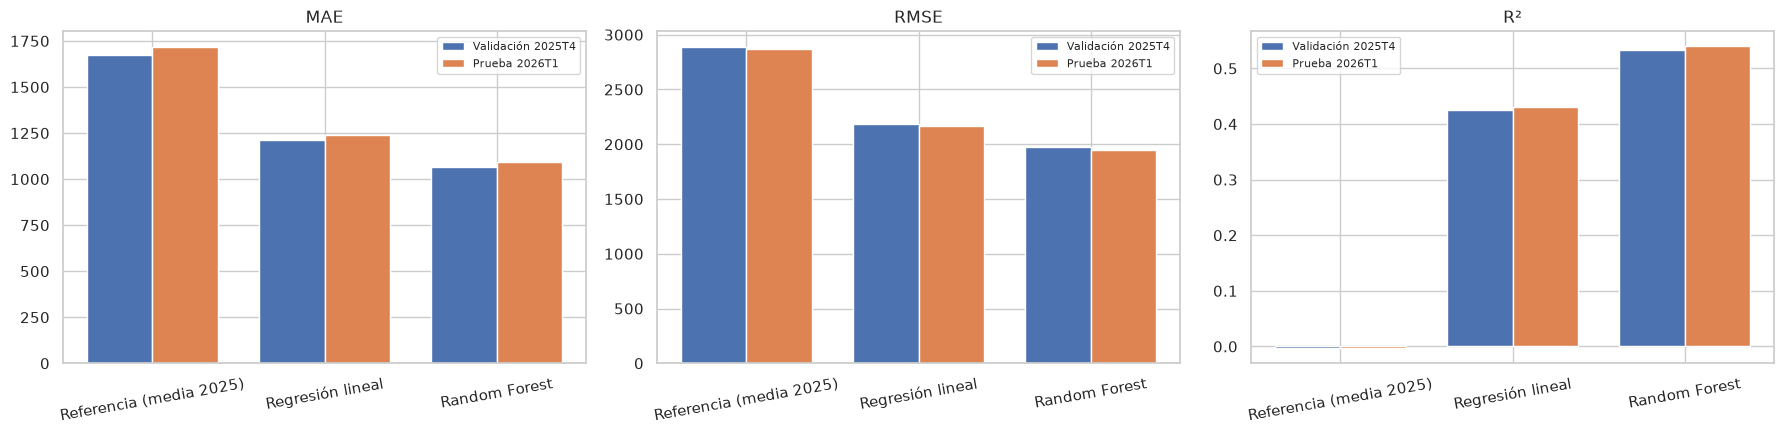

In [36]:
resumen_vt = pd.concat({"Validación 2025T4 (entrenado T1–T3)": comp_val[["MAE", "RMSE", "R²"]].set_axis(test_tab.index),
                        "Prueba 2026T1 (entrenado 2025 completo)": test_tab[["MAE", "RMSE", "R²"]]}, axis=1)
display(resumen_vt.round(3))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
etq = [t.split(" — ")[0] for t in test_tab.index]
for ax, met in zip(axes, ["MAE", "RMSE", "R²"]):
    x = np.arange(len(etq)); w = 0.38
    ax.bar(x - w/2, resumen_vt[("Validación 2025T4 (entrenado T1–T3)", met)], w, label="Validación 2025T4")
    ax.bar(x + w/2, resumen_vt[("Prueba 2026T1 (entrenado 2025 completo)", met)], w, label="Prueba 2026T1")
    ax.set_xticks(x); ax.set_xticklabels(etq, rotation=10); ax.set_title(met); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretación — evaluación final en 2026T1.**

| Modelo (entrenado con 2025 completo) | MAE | RMSE | R² | Error medio |
|---|---|---|---|---|
| Referencia (media 2025) | 1,718 | 2,871 | 0.00 | +144 |
| Regresión lineal (OLS) | 1,241 | 2,164 | 0.43 | +121 |
| **Random Forest (100 árboles, prof. 12)** | **1,095** | **1,945** | **0.54** | +109 |

- Ambos modelos se evaluaron sobre **los mismos 13,258 registros** elegibles de 2026T1 (verificado al unir las predicciones por clave).
- **El Random Forest sigue siendo superior en la prueba**: ≈ Q146 menos de MAE y ≈ Q219 menos de RMSE que la regresión lineal. Ambos superan claramente a la referencia (−28% y −36% de MAE).
- **Las métricas de prueba son muy parecidas a las de validación.** El MAE sube ≈ Q30 y el R² incluso mejora un poco, porque el modelo final se entrenó con un trimestre más. Los modelos **generalizan bien a un período nuevo** y no hay señales de sobreajuste a 2025.
- **Los tres modelos tienen un error medio positivo (+Q109 a +Q121)**: subestiman el salario de 2026 en promedio. Es coherente con el alza salarial observada durante 2025: el error medio de la referencia (+Q144) indica que el salario medio de 2026T1 (≈ Q3,566) supera en esa cantidad al promedio de 2025. Un modelo entrenado con salarios del pasado tiende a quedarse corto si los salarios siguen subiendo.
- Un R² ≈ 0.54 significa que casi la mitad de la variación salarial **no** se explica con estas seis variables: faltan factores como ocupación específica, rama de actividad, tamaño de la empresa, experiencia total o habilidades.

## 8. Visualización y análisis de errores (prueba 2026T1)

**Residuo = salario real − salario predicho.** Un residuo **positivo** indica que el modelo **subestimó** el salario; uno **negativo**, que lo **sobreestimó**.

Los gráficos usan **la misma muestra aleatoria de 5,000 registros** para ambos modelos (se muestrea una sola vez sobre la tabla que ya contiene las dos predicciones). Todas las métricas por grupo se calculan con **todos** los registros de prueba.

Registros en la muestra para graficar: 5000


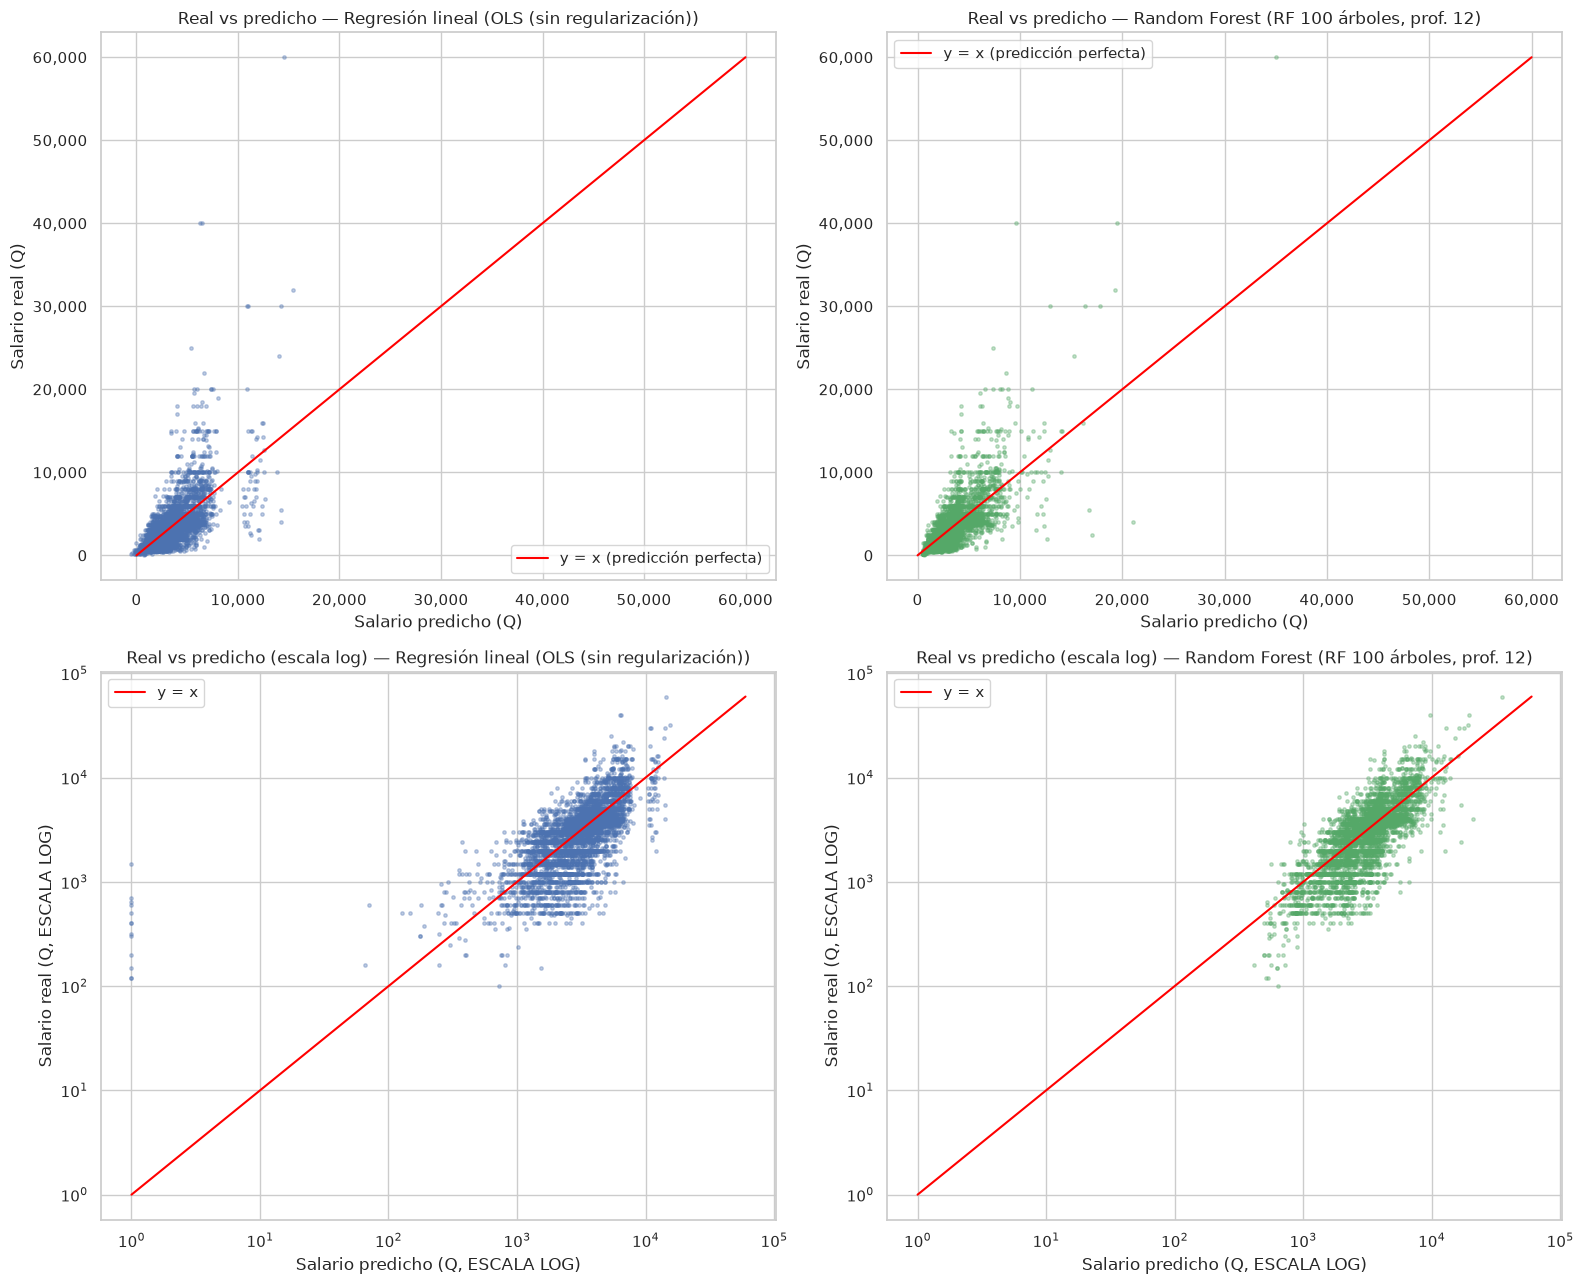

In [37]:
muestra26 = (pred26.sample(fraction=min(1.0, 6500 / n26), seed=SEED).limit(5000)
             .select(OBJ, "pred_lr", "pred_rf", "res_lr", "res_rf").toPandas())
print("Registros en la muestra para graficar:", len(muestra26))

MODELOS = [("pred_lr", "res_lr", f"Regresión lineal ({mejor_lr_nombre})", "#4C72B0"),
           ("pred_rf", "res_rf", f"Random Forest ({mejor_rf_nombre})", "#55A868")]

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
for j, (pc, rc, titulo, color) in enumerate(MODELOS):
    # (1) Real vs predicho — escala lineal
    ax = axes[0, j]
    ax.scatter(muestra26[pc], muestra26[OBJ], s=6, alpha=0.35, color=color)
    lim = max(muestra26[OBJ].max(), muestra26[pc].max())
    ax.plot([0, lim], [0, lim], color="red", lw=1.5, label="y = x (predicción perfecta)")
    ax.set_xlabel("Salario predicho (Q)"); ax.set_ylabel("Salario real (Q)")
    ax.set_title(f"Real vs predicho — {titulo}"); ax.legend()
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}")); ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    # (1b) Real vs predicho — ESCALA LOG en ambos ejes (sólo visual; predicciones <= 1 se dibujan en 1)
    ax = axes[1, j]
    ax.scatter(muestra26[pc].clip(lower=1), muestra26[OBJ], s=6, alpha=0.35, color=color)
    ax.plot([1, lim], [1, lim], color="red", lw=1.5, label="y = x")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Salario predicho (Q, ESCALA LOG)"); ax.set_ylabel("Salario real (Q, ESCALA LOG)")
    ax.set_title(f"Real vs predicho (escala log) — {titulo}"); ax.legend()
plt.tight_layout(); plt.show()

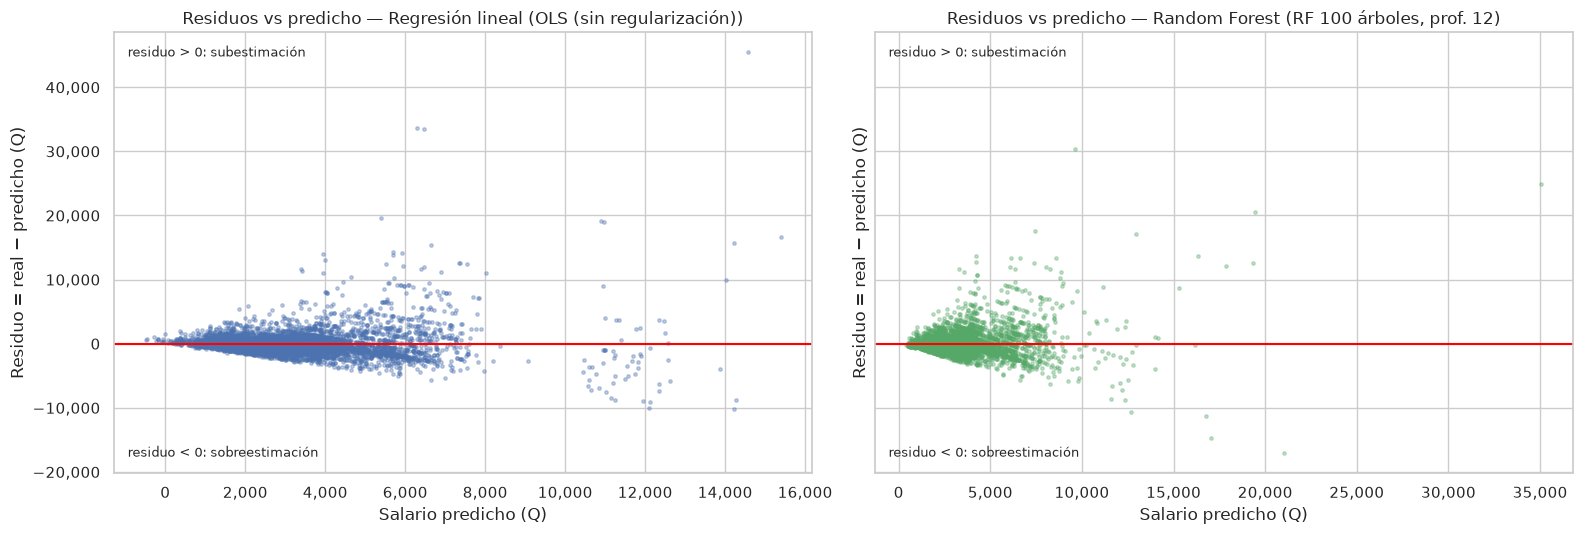

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
for ax, (pc, rc, titulo, color) in zip(axes, MODELOS):
    ax.scatter(muestra26[pc], muestra26[rc], s=6, alpha=0.35, color=color)
    ax.axhline(0, color="red", lw=1.5)
    ax.set_xlabel("Salario predicho (Q)"); ax.set_ylabel("Residuo = real − predicho (Q)")
    ax.set_title(f"Residuos vs predicho — {titulo}")
    ax.text(0.02, 0.97, "residuo > 0: subestimación", transform=ax.transAxes, va="top", fontsize=9)
    ax.text(0.02, 0.03, "residuo < 0: sobreestimación", transform=ax.transAxes, va="bottom", fontsize=9)
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}")); ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

### Tablas de MAE y error medio por grupo (todos los registros de prueba)

In [39]:
def errores_por(col, orden):
    pdf = (pred26.groupBy(col).agg(
              F.count("*").alias("n"),
              F.expr(f"percentile({OBJ}, 0.5)").alias("salario mediano real"),
              F.mean(F.abs("res_lr")).alias("MAE LR"), F.mean("res_lr").alias("Error medio LR"),
              F.mean(F.abs("res_rf")).alias("MAE RF"), F.mean("res_rf").alias("Error medio RF"))
           .toPandas().set_index(col).reindex(orden).dropna(subset=["n"]))
    pdf["n"] = pdf["n"].astype(int)
    return pdf.round(1)

err_edu = errores_por("nivel_educativo", ORDEN_EDU)
err_dom = errores_por("dominio", ORDEN_DOM)
print("Por nivel educativo"); display(err_edu)
print("Por dominio"); display(err_dom)

Por nivel educativo


,n,salario mediano real,MAE LR,Error medio LR,MAE RF,Error medio RF
nivel_educativo,,,,,,
Ninguno,1016,1680.0,823.5,109.3,643.1,-21.6
Preprimaria,80,2400.0,735.2,88.8,715.3,-323.0
Primaria,3957,2400.0,870.0,54.6,755.3,32.2
Básico,2164,3000.0,894.5,127.8,806.4,26.6
Diversificado,4117,3800.0,1109.3,104.0,1009.3,197.8
Superior,1729,5000.0,2566.4,295.5,2282.9,264.0
Maestría,183,10000.0,5552.9,-131.5,4600.4,-136.5
Doctorado,12,18500.0,12919.3,6062.7,10600.0,5202.7


Por dominio


,n,salario mediano real,MAE LR,Error medio LR,MAE RF,Error medio RF
dominio,,,,,,
Urbano metropolitano,5632,3900.0,1446.1,136.0,1299.8,230.8
Resto urbano,4846,3000.0,1189.6,134.3,1041.8,33.7
Rural nacional,2780,2160.0,913.6,65.2,772.2,-6.3


### Errores según el percentil del salario real

Se agrupan los registros de prueba según el **percentil de su salario real** (percentiles calculados sobre todo 2026T1) para ver si el error depende del nivel salarial.

Percentiles del salario real 2026T1: {'p10': 1000.0, 'p25': 2000.0, 'p50': 3200.0, 'p75': 4080.0, 'p90': 6000.0, 'p95': 8000.0, 'p99': 15000.0}


,n,salario mín,salario máx,salario real medio,predicción media LR,predicción media RF,Error medio LR,Error medio RF,MAE LR,MAE RF
tramo,,,,,,,,,,
< p10,1139,100.0,980.0,654.8,1605.2,1490.4,-950.4,-835.6,1028.7,845.6
p10–p25,2160,1000.0,1986.0,1398.3,2186.5,2142.8,-788.1,-744.5,963.0,838.9
p25–p50,3130,2000.0,3180.0,2518.4,2844.3,2841.2,-325.9,-322.8,910.9,742.6
p50–p75,3512,3200.0,4076.0,3718.0,3783.6,3749.9,-65.6,-31.8,822.9,703.6
p75–p90,1775,4080.0,5900.0,4709.1,4308.1,4291.4,401.0,417.7,1093.1,1095.2
p90–p95,730,6000.0,7980.0,6557.1,5251.1,5274.7,1306.0,1282.4,1830.5,1814.9
p95–p99,658,8000.0,14850.0,9659.3,6358.8,6767.6,3300.5,2891.7,3621.7,3222.1
≥ p99,154,15000.0,60000.0,19919.1,8253.0,9873.4,11666.1,10045.7,11666.1,10106.6


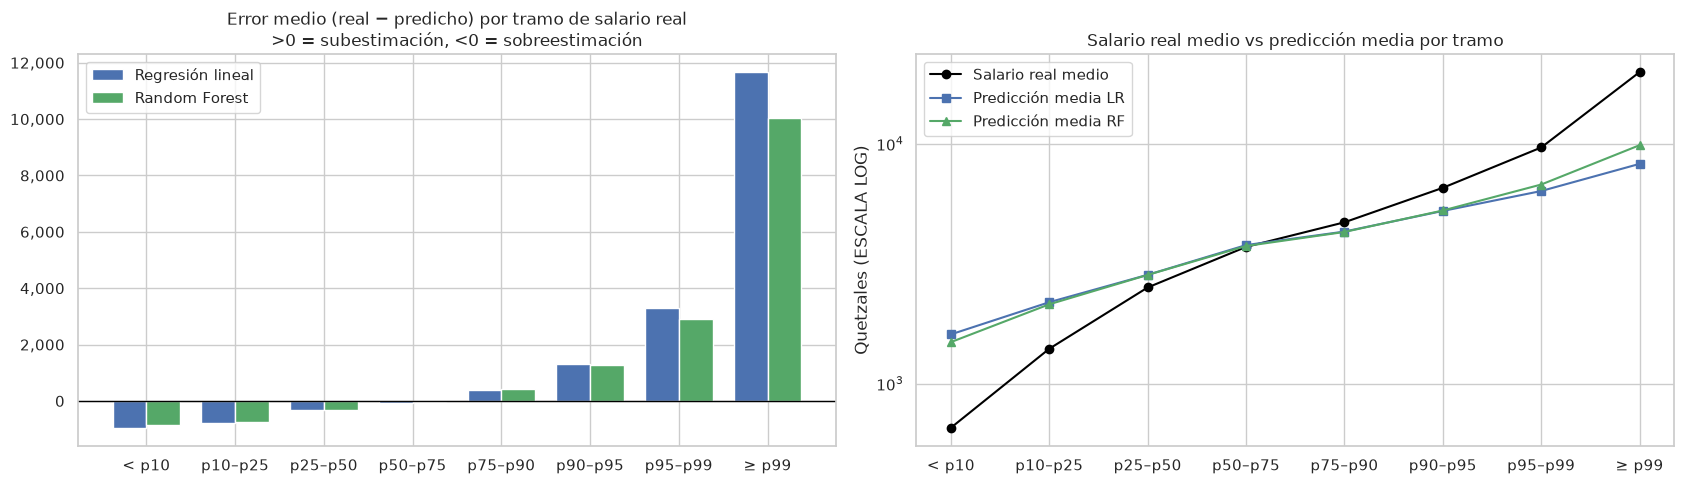

In [40]:
cortes = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
pcts = pred26.agg(F.expr(f"percentile({OBJ}, array({','.join(map(str, cortes))}))")).first()[0]
print("Percentiles del salario real 2026T1:", {f"p{int(c*100)}": v for c, v in zip(cortes, pcts)})

etiquetas = ["< p10", "p10–p25", "p25–p50", "p50–p75", "p75–p90", "p90–p95", "p95–p99", "≥ p99"]
expr_tramo = F.when(F.col(OBJ) < pcts[0], etiquetas[0])
for k in range(1, len(pcts)):
    expr_tramo = expr_tramo.when(F.col(OBJ) < pcts[k], etiquetas[k])
expr_tramo = expr_tramo.otherwise(etiquetas[-1])

err_pct = (pred26.withColumn("tramo", expr_tramo).groupBy("tramo").agg(
              F.count("*").alias("n"), F.min(OBJ).alias("salario mín"), F.max(OBJ).alias("salario máx"),
              F.mean(OBJ).alias("salario real medio"),
              F.mean("pred_lr").alias("predicción media LR"), F.mean("pred_rf").alias("predicción media RF"),
              F.mean("res_lr").alias("Error medio LR"), F.mean("res_rf").alias("Error medio RF"),
              F.mean(F.abs("res_lr")).alias("MAE LR"), F.mean(F.abs("res_rf")).alias("MAE RF"))
           .toPandas().set_index("tramo").reindex(etiquetas))
display(err_pct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
x = np.arange(len(etiquetas)); w = 0.38
axes[0].bar(x - w/2, err_pct["Error medio LR"], w, label="Regresión lineal", color="#4C72B0")
axes[0].bar(x + w/2, err_pct["Error medio RF"], w, label="Random Forest", color="#55A868")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_title("Error medio (real − predicho) por tramo de salario real\n>0 = subestimación, <0 = sobreestimación")
axes[1].plot(x, err_pct["salario real medio"], marker="o", color="black", label="Salario real medio")
axes[1].plot(x, err_pct["predicción media LR"], marker="s", color="#4C72B0", label="Predicción media LR")
axes[1].plot(x, err_pct["predicción media RF"], marker="^", color="#55A868", label="Predicción media RF")
axes[1].set_yscale("log"); axes[1].set_ylabel("Quetzales (ESCALA LOG)")
axes[1].set_title("Salario real medio vs predicción media por tramo")
for a in axes:
    a.set_xticks(x); a.set_xticklabels(etiquetas); a.legend()
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

### Influencia de los salarios extremos

Sin re‑entrenar ni recortar la evaluación principal, se mide cuánto del error cuadrático total proviene de los salarios más altos y cómo cambiarían las métricas si se excluyera el 1% superior (**análisis de sensibilidad complementario**, no reemplaza la comparación oficial).

In [41]:
p95_26, p99_26 = pcts[5], pcts[6]
agg = pred26.agg(
    F.sum(F.col("res_lr") ** 2).alias("sse_lr"), F.sum(F.col("res_rf") ** 2).alias("sse_rf"),
    F.sum(F.when(F.col(OBJ) >= p95_26, F.col("res_lr") ** 2).otherwise(0)).alias("sse_lr_top5"),
    F.sum(F.when(F.col(OBJ) >= p95_26, F.col("res_rf") ** 2).otherwise(0)).alias("sse_rf_top5"),
    F.sum(F.when(F.col(OBJ) >= p99_26, F.col("res_lr") ** 2).otherwise(0)).alias("sse_lr_top1"),
    F.sum(F.when(F.col(OBJ) >= p99_26, F.col("res_rf") ** 2).otherwise(0)).alias("sse_rf_top1"),
    F.mean((F.col(OBJ) >= p95_26).cast("double")).alias("frac_top5"),
    F.mean((F.col(OBJ) >= p99_26).cast("double")).alias("frac_top1")).first()

sin_top1 = pred26.filter(F.col(OBJ) < p99_26)
sens = pd.DataFrame({
    "Regresión lineal": {"% registros con salario ≥ p95": 100 * agg["frac_top5"],
                         "% del error cuadrático aportado por ≥ p95": 100 * agg["sse_lr_top5"] / agg["sse_lr"],
                         "% registros con salario ≥ p99": 100 * agg["frac_top1"],
                         "% del error cuadrático aportado por ≥ p99": 100 * agg["sse_lr_top1"] / agg["sse_lr"],
                         **{f"{k} sin ≥ p99": v for k, v in metricas(sin_top1.withColumn("prediction", F.col("pred_lr"))).items()}},
    "Random Forest":    {"% registros con salario ≥ p95": 100 * agg["frac_top5"],
                         "% del error cuadrático aportado por ≥ p95": 100 * agg["sse_rf_top5"] / agg["sse_rf"],
                         "% registros con salario ≥ p99": 100 * agg["frac_top1"],
                         "% del error cuadrático aportado por ≥ p99": 100 * agg["sse_rf_top1"] / agg["sse_rf"],
                         **{f"{k} sin ≥ p99": v for k, v in metricas(sin_top1.withColumn("prediction", F.col("pred_rf"))).items()}},
})
sens.round(3)

,Regresión lineal,Random Forest
% registros con salario ≥ p95,6.125,6.125
% del error cuadrático aportado por ≥ p95,63.775,61.874
% registros con salario ≥ p99,1.162,1.162
% del error cuadrático aportado por ≥ p99,46.215,43.194
MAE sin ≥ p99,1118.190,988.960
RMSE sin ≥ p99,1596.160,1474.256
R² sin ≥ p99,0.437,0.520
Error medio sin ≥ p99,-15.134,-7.752


**Interpretación — análisis de errores.**

**Gráficos de real vs predicho.** Ambos modelos se concentran alrededor de y = x en el rango típico (Q1,000–Q8,000), pero la nube es **más plana que la diagonal**: las predicciones abarcan un rango mucho más estrecho que los salarios reales. La mayoría de los salarios reales muy altos (Q20,000–Q60,000) reciben predicciones de sólo Q6,000–Q20,000 y quedan muy por encima de la línea. La excepción más visible es el salario de Q60,000, al que el RF le asigna ≈ Q35,000 y la regresión lineal ≈ Q14,500. La predicción máxima de la regresión lineal en toda la prueba es ≈ Q15,700. La regresión lineal muestra un grupo separado de predicciones entre Q11,000 y Q14,000 (personas con maestría o doctorado, donde un único coeficiente grande empuja la predicción), y algunas predicciones ≤ 0 para perfiles de muy bajo salario, que en el panel logarítmico aparecen en el borde izquierdo. El Random Forest no produce valores negativos y se ajusta mejor en la parte baja. Las franjas horizontales se deben a que los salarios se reportan en montos redondos (Q1,500, Q3,000, etc.).

**Residuos vs predicho.** Los residuos se distribuyen alrededor de cero, pero con **heterocedasticidad marcada**: su dispersión crece con el salario predicho (forma de embudo). Los residuos positivos grandes (subestimación de hasta Q30,000–Q45,000) son mucho más extremos que los negativos, reflejo de la cola derecha del salario. En la regresión lineal, el grupo de predicciones altas (Q11,000–Q14,000) tiene sobre todo residuos negativos: sobreestima a varios profesionales con posgrado.

**Por nivel educativo:** el MAE crece con el nivel educativo, igual que el salario y su dispersión: ≈ Q650–Q870 sin educación o con primaria, ≈ Q2,300–Q2,570 en superior, ≈ Q4,600–Q5,550 en maestría y más de Q10,000 en doctorado. Doctorado tiene sólo 12 registros de prueba, así que su error es muy inestable y **se subestima fuertemente** (error medio de +Q5,200 a +Q6,060). En los niveles bajos el error medio es pequeño. El RF casi no tiene sesgo en "ninguno" y "primaria".

**Por dominio:** el error absoluto es mayor en el **urbano metropolitano** (MAE ≈ Q1,300–Q1,450), donde los salarios son más altos y dispersos, y menor en el **rural** (≈ Q770–Q910). El RF subestima más en el área metropolitana (error medio +Q231) y queda casi insesgado en el área rural (−Q6).

**Por percentil del salario real — ¿se subestiman los salarios altos?** **Sí, de forma sistemática.** Ambos modelos muestran una clara **regresión hacia la media**:
- En el 10% de salarios más bajos (< Q1,000) **sobreestiman** en ≈ Q840–Q950: predicen ≈ Q1,500 cuando el salario real medio es Q655.
- Entre p50 y p75 el error medio es prácticamente cero.
- A partir de p75 el sesgo se invierte y crece: **subestiman** en ≈ Q400 (p75–p90), ≈ Q1,300 (p90–p95), ≈ Q2,900–Q3,300 (p95–p99) y ≈ **Q10,000–Q11,700 en el 1% superior** (salario real medio Q19,900 frente a predicciones de Q8,300–Q9,900).

Esto ocurre porque los seis predictores no distinguen bien a quienes ganan mucho de quienes ganan el promedio dentro de un mismo perfil. Al minimizar el error cuadrático, los modelos predicen valores cercanos a la media condicional, que queda por debajo de los salarios más altos. El RF atenúa un poco el sesgo en los extremos, pero no lo elimina.

**Influencia de los extremos:** el 6.1% de los registros con salario ≥ p95 (Q8,000) aporta **≈ 62–64% del error cuadrático total**, y el 1.2% con salario ≥ p99 (Q15,000) aporta ≈ 43–46%. Si esos pocos casos se excluyeran sólo de la evaluación (sensibilidad complementaria), el RMSE bajaría de Q2,164 a Q1,596 (LR) y de Q1,945 a Q1,474 (RF). El RMSE, por lo tanto, está dominado por unos cuantos salarios muy altos, y el MAE describe mejor el error típico. Por instrucción, la comparación oficial conserva todos los registros.